In [1]:
pip install numpy pandas scikit-learn seaborn matplotlib

In [2]:
import pandas as pd

df = pd.read_csv('/content/Online Sales Data.csv')
display(df.head())

,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,1/1/2024,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
1,10002,1/2/2024,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal
2,10003,1/3/2024,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card
3,10004,1/4/2024,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card
4,10005,1/5/2024,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal


In [4]:
print('Data Types:')
display(df.info())

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    240 non-null    int64  
 1   Date              240 non-null    object 
 2   Product Category  240 non-null    object 
 3   Product Name      240 non-null    object 
 4   Units Sold        240 non-null    int64  
 5   Unit Price        240 non-null    float64
 6   Total Revenue     240 non-null    float64
 7   Region            240 non-null    object 
 8   Payment Method    240 non-null    object 
dtypes: float64(2), int64(2), object(5)
memory usage: 17.0+ KB


None

In [5]:
print('\nMissing Values:')
display(df.isnull().sum())


Missing Values:


,0
Transaction ID,0
Date,0
Product Category,0
Product Name,0
Units Sold,0
Unit Price,0
Total Revenue,0
Region,0
Payment Method,0


In [6]:
df['Date'] = pd.to_datetime(df['Date'])
print('Data Types after Date conversion:')
display(df.info())

Data Types after Date conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    240 non-null    int64         
 1   Date              240 non-null    datetime64[ns]
 2   Product Category  240 non-null    object        
 3   Product Name      240 non-null    object        
 4   Units Sold        240 non-null    int64         
 5   Unit Price        240 non-null    float64       
 6   Total Revenue     240 non-null    float64       
 7   Region            240 non-null    object        
 8   Payment Method    240 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 17.0+ KB


None

### Outlier Detection for Total Revenue

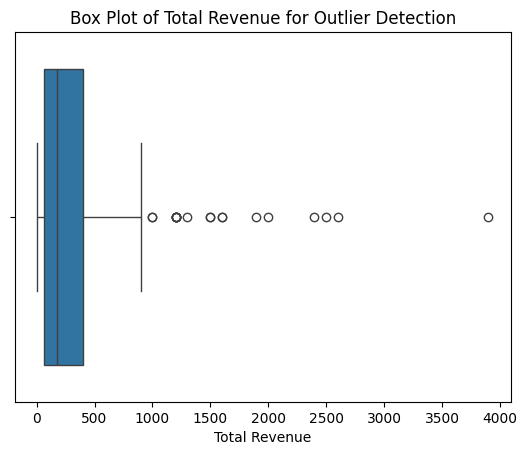

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(x=df['Total Revenue'])
plt.title('Box Plot of Total Revenue for Outlier Detection')
plt.xlabel('Total Revenue')
plt.show()

In [8]:
# Calculate IQR for Total Revenue
Q1 = df['Total Revenue'].quantile(0.25)
Q3 = df['Total Revenue'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['Total Revenue'] < lower_bound) | (df['Total Revenue'] > upper_bound)]

print(f"Q1 (25th percentile): {Q1:.2f}")
print(f"Q3 (75th percentile): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower bound for outliers: {lower_bound:.2f}")
print(f"Upper bound for outliers: {upper_bound:.2f}")

if not outliers.empty:
    print(f"\nNumber of outliers detected: {len(outliers)}")
    print("Outlier data points (first 5 if more):")
    display(outliers.head())
else:
    print("\nNo outliers detected based on the IQR method.")

Q1 (25th percentile): 62.97
Q3 (75th percentile): 399.23
IQR: 336.26
Lower bound for outliers: -441.42
Upper bound for outliers: 903.62

Number of outliers detected: 19
Outlier data points (first 5 if more):


,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
6,10007,2024-01-07,Electronics,MacBook Pro 16-inch,1,2499.99,2499.99,North America,Credit Card
7,10008,2024-01-08,Home Appliances,Blueair Classic 480i,2,599.99,1199.98,Europe,PayPal
12,10013,2024-01-13,Electronics,Samsung Galaxy Tab S8,2,749.99,1499.98,North America,Credit Card
18,10019,2024-01-19,Electronics,Garmin Forerunner 945,2,499.99,999.98,North America,Credit Card


### Comparison of Total Revenue with and without Outliers

In [12]:
# Calculate total revenue from the original DataFrame
total_revenue_original = df['Total Revenue'].sum()

# Create a DataFrame without outliers
df_cleaned = df[~((df['Total Revenue'] < lower_bound) | (df['Total Revenue'] > upper_bound))]

# Calculate total revenue from the cleaned DataFrame
total_revenue_cleaned = df_cleaned['Total Revenue'].sum()

print(f"Total Revenue (with outliers): ${total_revenue_original:,.2f}")
print(f"Total Revenue (without outliers): ${total_revenue_cleaned:,.2f}")
print(f"Difference: ${total_revenue_original - total_revenue_cleaned:,.2f}")
print(f"Percentage change: {((total_revenue_original - total_revenue_cleaned) / total_revenue_original * 100):.2f}%")

Total Revenue (with outliers): $80,567.85
Total Revenue (without outliers): $48,574.13
Difference: $31,993.72
Percentage change: 39.71%


### Histogram Comparison: Total Revenue (Original vs. Cleaned Data)

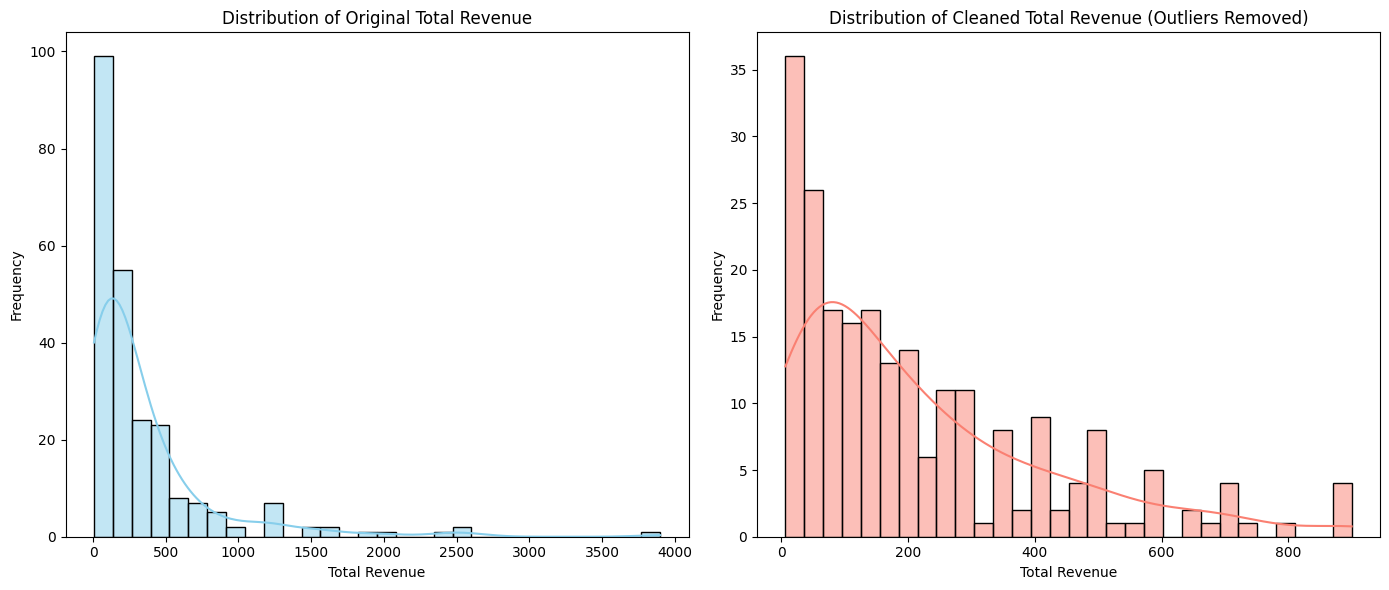

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Histogram for Original Total Revenue
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(df['Total Revenue'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Original Total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Frequency')

# Histogram for Cleaned Total Revenue (without outliers)
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.histplot(df_cleaned['Total Revenue'], kde=True, bins=30, color='salmon')
plt.title('Distribution of Cleaned Total Revenue (Outliers Removed)')
plt.xlabel('Total Revenue')
plt.ylabel('Frequency')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

### Analysis of Outliers by Product Category

Outliers by Product Category:


,Product Category,Outlier Count
0,Electronics,14
1,Home Appliances,3
2,Sports,2


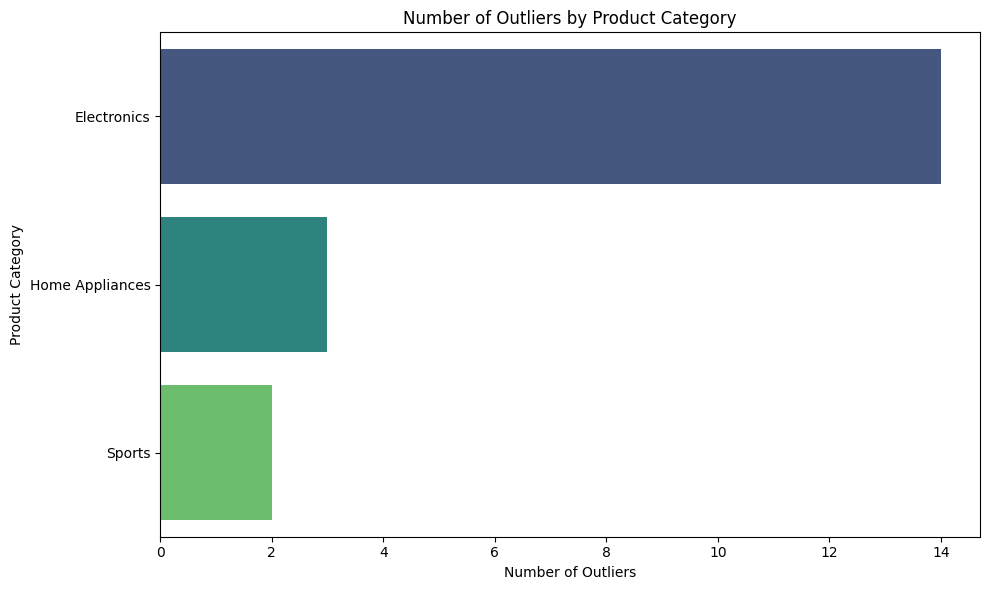

In [17]:
outliers_by_category = outliers['Product Category'].value_counts().reset_index()
outliers_by_category.columns = ['Product Category', 'Outlier Count']

print("Outliers by Product Category:")
display(outliers_by_category)

# Optionally, visualize this distribution
plt.figure(figsize=(10, 6))
sns.barplot(x='Outlier Count', y='Product Category', data=outliers_by_category.sort_values(by='Outlier Count', ascending=False), hue='Product Category', palette='viridis', legend=False)
plt.title('Number of Outliers by Product Category')
plt.xlabel('Number of Outliers')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

In [15]:
total_revenue_by_category = df.groupby('Product Category')['Total Revenue'].sum().reset_index()
total_revenue_by_category.columns = ['Product Category', 'Total Revenue (Original)']

outlier_revenue_by_category = outliers.groupby('Product Category')['Total Revenue'].sum().reset_index()
outlier_revenue_by_category.columns = ['Product Category', 'Outlier Revenue']

# Merge the two DataFrames
category_revenue_summary = pd.merge(total_revenue_by_category, outlier_revenue_by_category, on='Product Category', how='left')

# Fill NaN values (categories with no outliers will have NaN outlier revenue) with 0
category_revenue_summary['Outlier Revenue'] = category_revenue_summary['Outlier Revenue'].fillna(0)

# Calculate the percentage of outlier revenue per category
category_revenue_summary['Percentage Outlier Revenue'] = (category_revenue_summary['Outlier Revenue'] / category_revenue_summary['Total Revenue (Original)']) * 100

print("Percentage of total sales that are outliers per category:")
display(category_revenue_summary.sort_values(by='Percentage Outlier Revenue', ascending=False))

Percentage of total sales that are outliers per category:


,Product Category,Total Revenue (Original),Outlier Revenue,Percentage Outlier Revenue
3,Electronics,34982.41,23698.79,67.744875
4,Home Appliances,18646.16,5399.94,28.960065
5,Sports,14326.52,2894.99,20.207210
0,Beauty Products,2621.90,0.00,0.000000
1,Books,1861.93,0.00,0.000000
2,Clothing,8128.93,0.00,0.000000


From the table above, we can see the percentage of each product category's total revenue that is made up of outlier sales. For example, 'Electronics' has a significant portion of its sales designated as outliers.

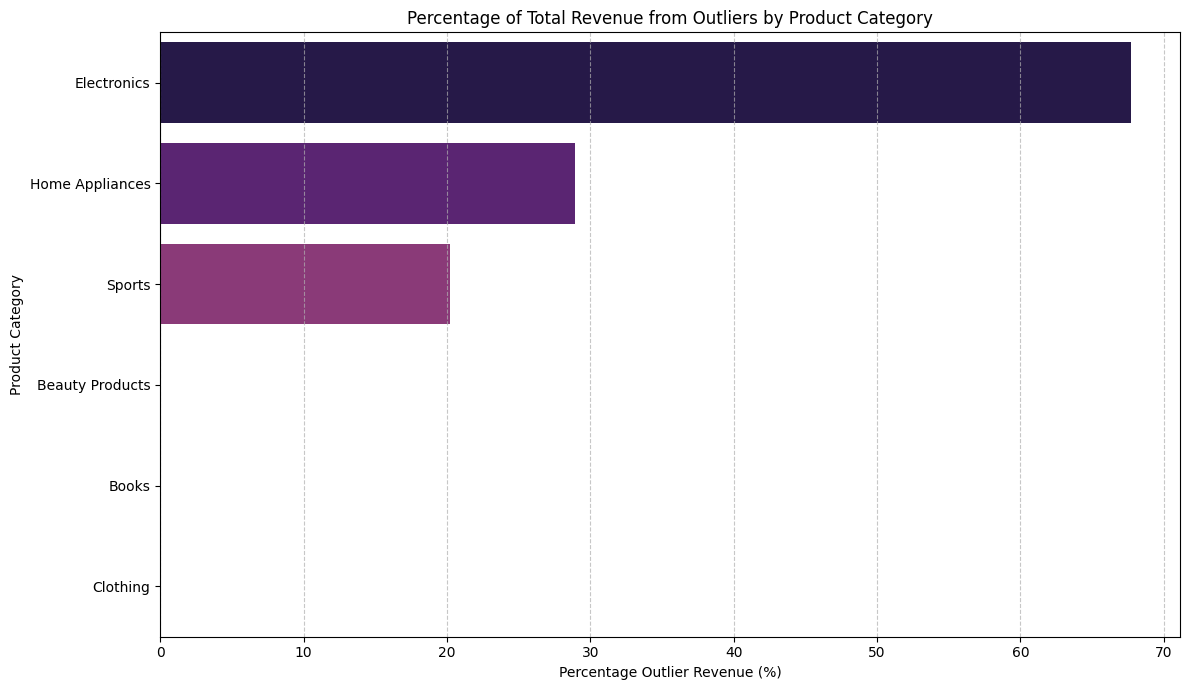

In [18]:
# Optionally, visualize the percentage of outlier revenue by category
plt.figure(figsize=(12, 7))
sns.barplot(x='Percentage Outlier Revenue', y='Product Category', data=category_revenue_summary.sort_values(by='Percentage Outlier Revenue', ascending=False), hue='Product Category', palette='magma', legend=False)
plt.title('Percentage of Total Revenue from Outliers by Product Category')
plt.xlabel('Percentage Outlier Revenue (%)')
plt.ylabel('Product Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [21]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns in df_cleaned that are relevant for scaling
# Exclude 'Transaction ID' as it's an identifier, and 'Date' as it's datetime
numerical_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Transaction ID' in numerical_cols:
    numerical_cols.remove('Transaction ID')

print(f"Numerical columns to scale: {numerical_cols}")

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply scaling to the numerical columns of df_cleaned
df_cleaned_scaled = df_cleaned.copy()
df_cleaned_scaled[numerical_cols] = scaler.fit_transform(df_cleaned_scaled[numerical_cols])

print("\nScaled df_cleaned DataFrame (first 5 rows):")
display(df_cleaned_scaled.head())

Numerical columns to scale: ['Units Sold', 'Unit Price', 'Total Revenue']

Scaled df_cleaned DataFrame (first 5 rows):


,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,-0.895308,2.070963,1.368816,Europe,PayPal
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,0.586812,-0.432687,-0.047984,Asia,Debit Card
3,10004,2024-01-04,Books,The Da Vinci Code,1.327873,-0.747099,-0.761270,North America,Credit Card
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,-0.895308,-0.316238,-0.634108,Europe,PayPal
5,10006,2024-01-06,Sports,Wilson Evolution Basketball,2.068933,-0.665585,-0.341193,Asia,Credit Card


The numerical features in `df_cleaned` have now been scaled. The `display(df_cleaned_scaled.head())` output above shows the transformed values for 'Units Sold', 'Unit Price', and 'Total Revenue'.

### Correlation Analysis of Scaled Numerical Features

Correlation Matrix of Scaled Numerical Features:


,Units Sold,Unit Price,Total Revenue
Units Sold,1.000000,-0.426520,-0.123505
Unit Price,-0.426520,1.000000,0.843628
Total Revenue,-0.123505,0.843628,1.000000


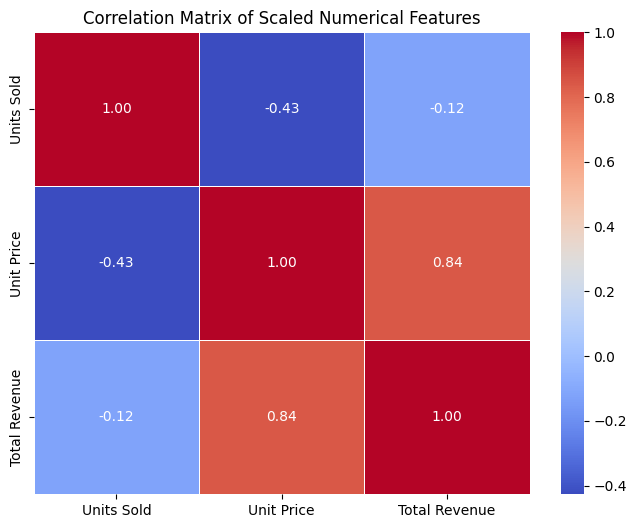

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for the scaled numerical features
correlation_matrix = df_cleaned_scaled[numerical_cols].corr()

print("Correlation Matrix of Scaled Numerical Features:")
display(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Scaled Numerical Features')
plt.show()

### Impact of Units Sold vs. Unit Price on Total Revenue

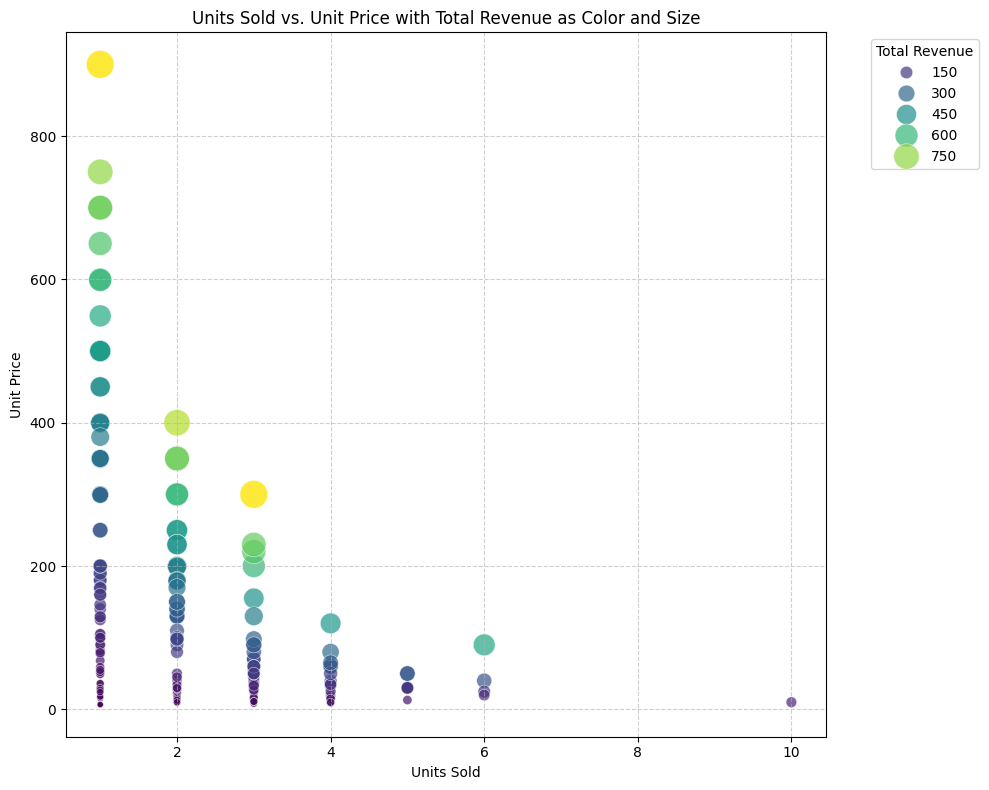

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
scatter_plot = sns.scatterplot(
    x='Units Sold',
    y='Unit Price',
    hue='Total Revenue', # Color points based on Total Revenue
    size='Total Revenue', # Size points based on Total Revenue
    data=df_cleaned,
    palette='viridis', # Choose a color palette
    sizes=(20, 400), # Define the range of sizes for the points
    alpha=0.7 # Add some transparency
)

plt.title('Units Sold vs. Unit Price with Total Revenue as Color and Size')
plt.xlabel('Units Sold')
plt.ylabel('Unit Price')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Total Revenue', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Encoding Categorical Features

In [24]:
import pandas as pd

# Identify categorical columns (excluding 'Date' and 'Transaction ID' if present in object types)
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns.tolist()

print(f"Categorical columns to encode: {categorical_cols}")

# Apply one-hot encoding to the identified categorical columns
df_encoded = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True) # drop_first avoids multicollinearity

print("\nDataFrame after one-hot encoding (first 5 rows):")
display(df_encoded.head())

Categorical columns to encode: ['Product Category', 'Product Name', 'Region', 'Payment Method']

DataFrame after one-hot encoding (first 5 rows):


,Transaction ID,Date,Units Sold,Unit Price,Total Revenue,Product Category_Books,Product Category_Clothing,Product Category_Electronics,Product Category_Home Appliances,Product Category_Sports,...,Product Name_Yeti Rambler Tumbler,Product Name_Yeti Roadie 24 Cooler,Product Name_Yeti Tundra Haul Portable Wheeled Cooler,Product Name_Youth to the People Superfood Antioxidant Cleanser,Product Name_Zara Summer Dress,Product Name_iRobot Braava Jet M6,Region_Europe,Region_North America,Payment Method_Debit Card,Payment Method_PayPal
1,10002,2024-01-02,1,499.99,499.99,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
2,10003,2024-01-03,3,69.99,209.97,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,10004,2024-01-04,4,15.99,63.96,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,10005,2024-01-05,1,89.99,89.99,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
5,10006,2024-01-06,5,29.99,149.95,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


### Exploring Correlations with Encoded Categorical Features

In [25]:
# Drop 'Transaction ID' and 'Date' columns for correlation analysis as they are not features for direct correlation
df_for_correlation = df_encoded.drop(columns=['Transaction ID', 'Date'])

# Calculate correlations with 'Total Revenue'
correlations_with_revenue = df_for_correlation.corr()['Total Revenue'].sort_values(ascending=False)

print("Top Positive Correlations with Total Revenue (including encoded features):")
display(correlations_with_revenue.head(10))

print("\nTop Negative Correlations with Total Revenue (including encoded features):")
display(correlations_with_revenue.tail(10))


Top Positive Correlations with Total Revenue (including encoded features):


,Total Revenue
Total Revenue,1.000000
Unit Price,0.843628
Product Category_Electronics,0.382081
Product Category_Home Appliances,0.302777
Product Name_Google Pixel 6 Pro,0.224029
Product Name_De'Longhi Magnifica Espresso Machine,0.224029
Product Name_Bose SoundLink Revolve+ Speaker,0.224022
Product Name_Nintendo Switch,0.224022
Product Category_Sports,0.180398
Product Name_Dyson Supersonic Hair Dryer,0.177491



Top Negative Correlations with Total Revenue (including encoded features):


,Total Revenue
Product Name_Biore UV Aqua Rich Watery Essence Sunscreen,-0.067450
Product Name_The Ordinary Hyaluronic Acid Serum,-0.070151
Product Name_The Ordinary Caffeine Solution 5% + EGCG,-0.070184
Product Name_The Ordinary Niacinamide Serum,-0.070250
Product Name_The Silent Patient by Alex Michaelides,-0.071109
Product Name_The Catcher in the Rye by J.D. Salinger,-0.081851
Product Name_Dune by Frank Herbert,-0.085812
Product Name_The Girl with the Dragon Tattoo by Stieg Larsson,-0.090249
Units Sold,-0.123505
Product Category_Books,-0.397860


### Top 5 Highest Revenue Products in Electronics Category

In [26]:
# Filter for 'Electronics' category from the cleaned DataFrame
electronics_df = df_cleaned[df_cleaned['Product Category'] == 'Electronics']

# Group by 'Product Name' and sum 'Total Revenue'
top_electronics_products = electronics_df.groupby('Product Name')['Total Revenue'].sum().reset_index()

# Sort in descending order and get the top 5
top_5_electronics_revenue = top_electronics_products.sort_values(by='Total Revenue', ascending=False).head(5)

print("Top 5 Highest Revenue Products in Electronics Category (from cleaned data):")
display(top_5_electronics_revenue)

Top 5 Highest Revenue Products in Electronics Category (from cleaned data):


,Product Name,Total Revenue
24,Sony WH-1000XM4 Headphones,1049.97
13,Google Pixel 6 Pro,899.99
18,Nintendo Switch,899.97
9,Bose SoundLink Revolve+ Speaker,899.97
10,Canon EOS Rebel T7i DSLR Camera,749.99


## Customer Segmentation using K-Means Clustering

To identify customer segments, we will use K-Means clustering. We'll focus on features related to revenue and product categories. First, we'll prepare the data by selecting relevant numerical features and one-hot encoding the product categories. Then, we'll scale these features before applying the clustering algorithm.

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical features for clustering from df_cleaned
numerical_features = df_cleaned[['Units Sold', 'Unit Price', 'Total Revenue']]

# One-hot encode 'Product Category' from df_cleaned
product_category_encoded = pd.get_dummies(df_cleaned['Product Category'], prefix='Category', drop_first=True)

# Combine numerical and encoded categorical features
features_for_clustering = pd.concat([numerical_features, product_category_encoded], axis=1)

# Scale all features
scaler_clustering = StandardScaler()
scaled_features = scaler_clustering.fit_transform(features_for_clustering)

# Convert scaled features back to a DataFrame for easier handling
scaled_features_df = pd.DataFrame(scaled_features, columns=features_for_clustering.columns, index=df_cleaned.index)

print("Features prepared and scaled for clustering (first 5 rows):")
display(scaled_features_df.head())

Features prepared and scaled for clustering (first 5 rows):


,Units Sold,Unit Price,Total Revenue,Category_Books,Category_Clothing,Category_Electronics,Category_Home Appliances,Category_Sports
1,-0.895308,2.070963,1.368816,-0.470100,-0.470100,-0.365148,2.230016,-0.455687
2,0.586812,-0.432687,-0.047984,-0.470100,2.127205,-0.365148,-0.448427,-0.455687
3,1.327873,-0.747099,-0.761270,2.127205,-0.470100,-0.365148,-0.448427,-0.455687
4,-0.895308,-0.316238,-0.634108,-0.470100,-0.470100,-0.365148,-0.448427,-0.455687
5,2.068933,-0.665585,-0.341193,-0.470100,-0.470100,-0.365148,-0.448427,2.194491


### Determining the Optimal Number of Clusters (K) using the Elbow Method

The Elbow Method helps us find the optimal number of clusters (K) for K-Means. We calculate the Within-Cluster Sum of Squares (WCSS) for a range of K values and look for the 'elbow point' in the plot, which indicates a good balance between minimizing WCSS and having a reasonable number of clusters.

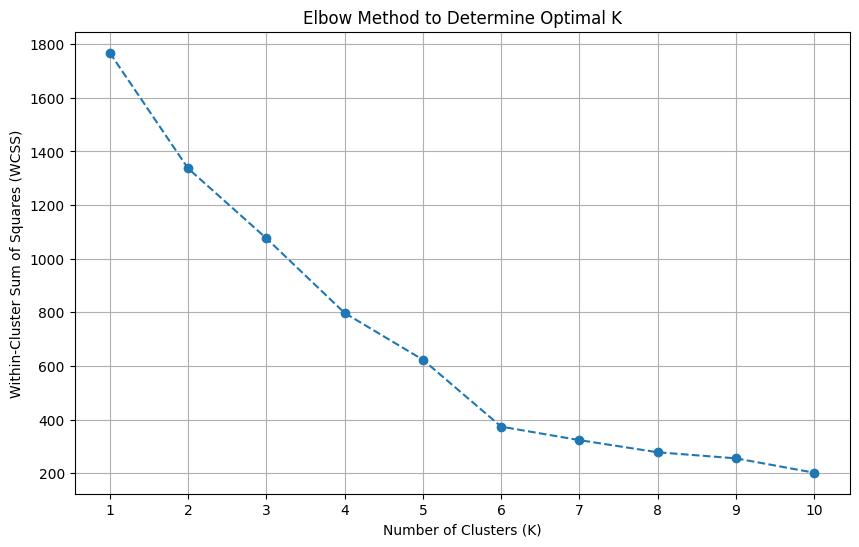

In [28]:
# Calculate WCSS for different number of clusters
wcss = []
max_clusters = 10 # Adjust as needed

for i in range(1, max_clusters + 1):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init='auto')
    kmeans.fit(scaled_features_df)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_clusters + 1), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to Determine Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True)
plt.xticks(range(1, max_clusters + 1))
plt.show()

From the Elbow plot, choose an appropriate number of clusters (K). Let's assume for this example, we choose K=3 (or observe the plot to make a more informed decision).

### Applying K-Means Clustering and Analyzing Customer Segments

Now, we'll apply K-Means with the chosen number of clusters and analyze the characteristics of each segment.

In [29]:
# Apply K-Means with the chosen number of clusters (e.g., K=3 based on a typical elbow observation)
# You might need to adjust n_clusters based on the previous elbow plot
optimal_k = 3 # Placeholder, adjust based on your elbow plot observation
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init='auto')
clusters = kmeans.fit_predict(scaled_features_df)

# Add cluster labels to the original cleaned DataFrame
df_cleaned_with_clusters = df_cleaned.copy()
df_cleaned_with_clusters['Cluster'] = clusters

print(f"DataFrame with assigned clusters (first 5 rows, K={optimal_k}):")
display(df_cleaned_with_clusters.head())

# Analyze the characteristics of each cluster
cluster_summary = df_cleaned_with_clusters.groupby('Cluster').agg(
    mean_units_sold=('Units Sold', 'mean'),
    mean_unit_price=('Unit Price', 'mean'),
    mean_total_revenue=('Total Revenue', 'mean'),
    most_common_category=('Product Category', lambda x: x.mode()[0]) # Most frequent category
).reset_index()

print(f"\nCluster Summary (K={optimal_k}):")
display(cluster_summary)

DataFrame with assigned clusters (first 5 rows, K=3):


,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method,Cluster
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal,2
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card,0
3,10004,2024-01-04,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card,0
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal,0
5,10006,2024-01-06,Sports,Wilson Evolution Basketball,5,29.99,149.95,Asia,Credit Card,1



Cluster Summary (K=3):


,Cluster,mean_units_sold,mean_unit_price,mean_total_revenue,most_common_category
0,0,2.581967,45.676066,104.939836,Books
1,1,2.263158,198.851842,300.829737,Sports
2,2,1.426230,307.578033,399.015410,Home Appliances


### Visualizing Customer Segments (using Total Revenue and Product Category)

To better understand the segments, we can visualize them. Since we have multiple dimensions, we can use dimensionality reduction techniques like PCA, or simply plot key features against each other. Here, we'll visualize `Total Revenue` across clusters and also the distribution of `Product Category` within each cluster.

/tmp/ipykernel_749/4237698116.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Total Revenue', data=df_cleaned_with_clusters, palette='viridis')


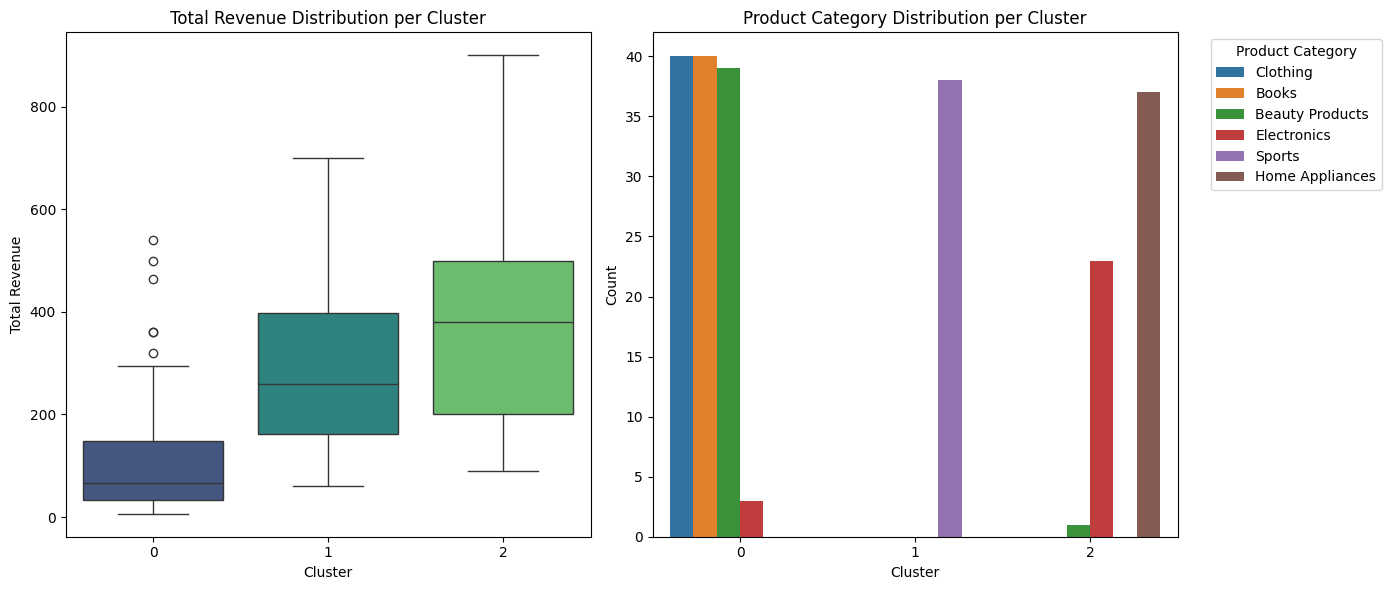

In [30]:
plt.figure(figsize=(14, 6))

# Box plot of Total Revenue by Cluster
plt.subplot(1, 2, 1)
sns.boxplot(x='Cluster', y='Total Revenue', data=df_cleaned_with_clusters, palette='viridis')
plt.title('Total Revenue Distribution per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Total Revenue')

# Count plot of Product Category by Cluster
plt.subplot(1, 2, 2)
sns.countplot(x='Cluster', hue='Product Category', data=df_cleaned_with_clusters, palette='tab10')
plt.title('Product Category Distribution per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Revenue and Sales Performance Forecasting

To forecast revenue and sales performance, we will treat the problem as a time-series forecasting task. We'll aggregate the data daily, resample it to a suitable frequency (e.g., weekly or monthly if daily is too sparse), and then use a suitable model like ARIMA or Prophet for forecasting.

Weekly Revenue data (first 5 rows):


,ds,y
0,2024-01-07,1013.86
1,2024-01-14,1511.87
2,2024-01-21,1767.86
3,2024-01-28,1064.87
4,2024-02-04,1569.81


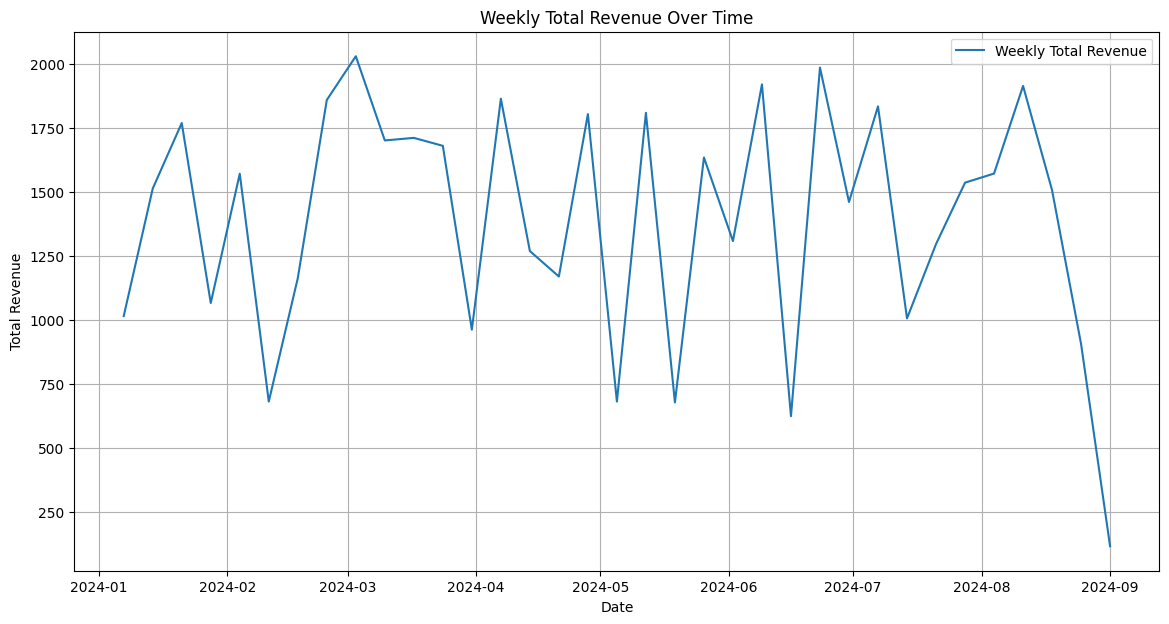

In [31]:
import warnings
warnings.filterwarnings('ignore') # Suppress warnings, especially from Prophet

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.dates as mdates

# 1. Prepare Data for Time-Series Forecasting
# Aggregate daily total revenue
daily_revenue = df_cleaned.groupby('Date')['Total Revenue'].sum().reset_index()

# Set Date as index
daily_revenue = daily_revenue.set_index('Date')

# Resample to weekly data, summing up total revenue for each week
weekly_revenue = daily_revenue['Total Revenue'].resample('W').sum().reset_index()
weekly_revenue.columns = ['ds', 'y'] # Prophet-style column names

print("Weekly Revenue data (first 5 rows):")
display(weekly_revenue.head())

# Visualize the weekly revenue trend
plt.figure(figsize=(14, 7))
plt.plot(weekly_revenue['ds'], weekly_revenue['y'], label='Weekly Total Revenue')
plt.title('Weekly Total Revenue Over Time')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.legend()
plt.show()

### Time Series Decomposition

Before modeling, let's decompose the weekly revenue time series into its trend, seasonal, and residual components to understand its underlying patterns.

Not enough data for robust seasonal decomposition with a yearly period (52 weeks).
Attempting decomposition with a smaller, heuristic period (e.g., 4 weeks).


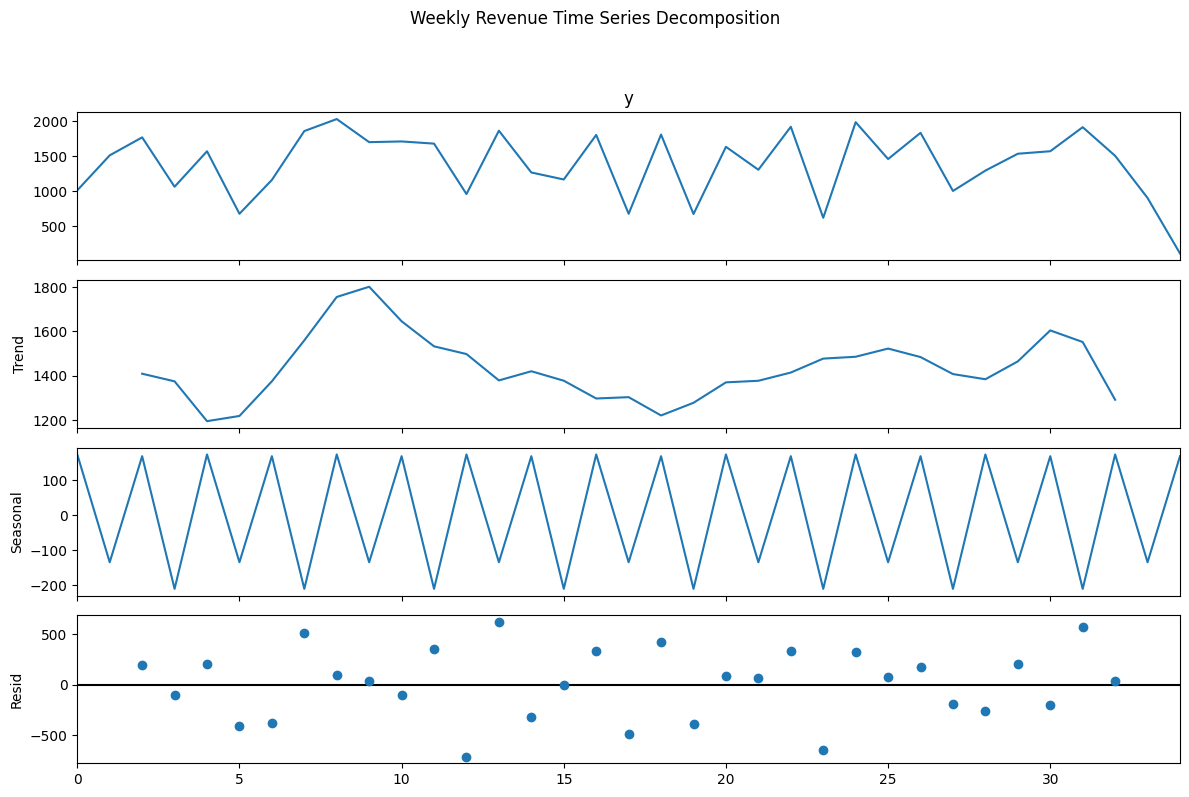

In [32]:
# Perform seasonal decomposition (assuming an additive model for simplicity)
# We need to ensure the time series has enough data points for the frequency
# Let's assume a weekly seasonality of 52 weeks for annual cycles, or try simpler if data is short.
# For data spanning less than a year, a simpler approach or different frequency might be needed.

# Check the length of the time series
if len(weekly_revenue) > 2 * 52: # At least two cycles for robust decomposition
    decomposition = seasonal_decompose(weekly_revenue['y'], model='additive', period=52) # Assuming yearly seasonality
else:
    print("Not enough data for robust seasonal decomposition with a yearly period (52 weeks).")
    print("Attempting decomposition with a smaller, heuristic period (e.g., 4 weeks).")
    try:
        decomposition = seasonal_decompose(weekly_revenue['y'], model='additive', period=4) # Heuristic weekly seasonality
    except ValueError:
        print("Seasonal decomposition failed even with a 4-week period. Data might be too short or irregular.")
        decomposition = None

if decomposition:
    fig = decomposition.plot()
    fig.set_size_inches(12, 8)
    plt.suptitle('Weekly Revenue Time Series Decomposition', y=1.02) # Adjust title position
    plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
    plt.show()

## Splitting the Dataset into Training and Test Sets

For building a predictive model (e.g., for revenue or sales performance), we need to split our processed data (`df_encoded`) into training and testing sets. This allows us to train the model on one portion of the data and evaluate its performance on unseen data. We'll use `Total Revenue` as our target variable.

In [36]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
# Exclude 'Transaction ID' and 'Date' as they are not predictive features for this model
X = df_encoded.drop(columns=['Total Revenue', 'Transaction ID', 'Date'])
y = df_encoded['Total Revenue']

# Split the data into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nFirst 5 rows of X_train:")
display(X_train.head())

Shape of X_train: (176, 224)
Shape of X_test: (45, 224)
Shape of y_train: (176,)
Shape of y_test: (45,)

First 5 rows of X_train:


,Units Sold,Unit Price,Product Category_Books,Product Category_Clothing,Product Category_Electronics,Product Category_Home Appliances,Product Category_Sports,Product Name_Adidas 3-Stripes Shorts,Product Name_Adidas Essential Track Pants,Product Name_Adidas FIFA World Cup Football,...,Product Name_Yeti Rambler Tumbler,Product Name_Yeti Roadie 24 Cooler,Product Name_Yeti Tundra Haul Portable Wheeled Cooler,Product Name_Youth to the People Superfood Antioxidant Cleanser,Product Name_Zara Summer Dress,Product Name_iRobot Braava Jet M6,Region_Europe,Region_North America,Payment Method_Debit Card,Payment Method_PayPal
237,3,10.99,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
128,3,98.00,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
157,1,499.95,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
139,1,139.99,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
180,1,649.99,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


## Training a Regression Model and Visualizing Actual vs. Predicted Revenue

Now that we have split our data, we can train a regression model to predict 'Total Revenue'. We'll start with a simple Linear Regression model and then visualize its performance by plotting the actual revenue from the test set against the model's predictions.

Mean Absolute Error (MAE): 169.72
R-squared (R2) Score: -0.42


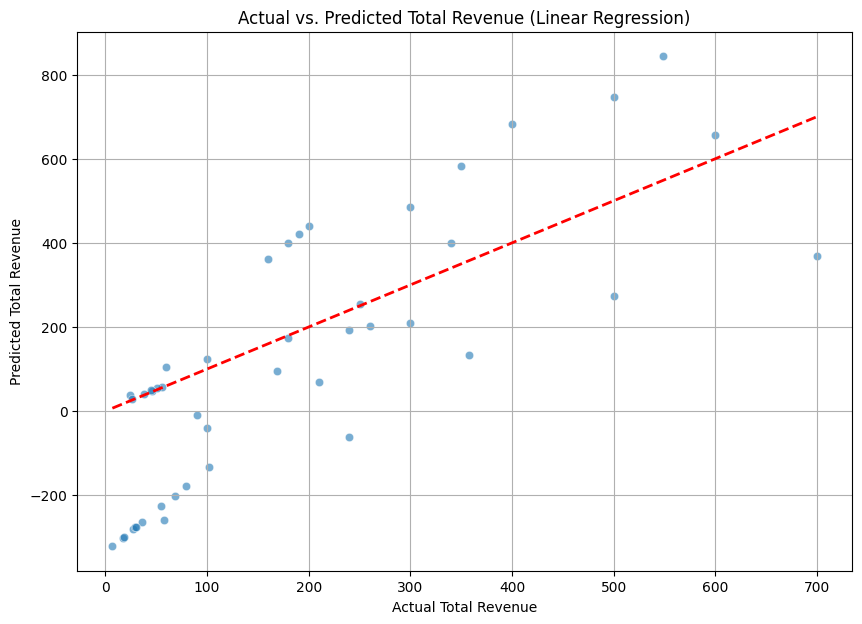

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = linear_model.predict(X_test)

# Evaluate the model (optional, but good practice)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

# Plot Actual vs. Predicted Revenue
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Ideal line
plt.title('Actual vs. Predicted Total Revenue (Linear Regression)')
plt.xlabel('Actual Total Revenue')
plt.ylabel('Predicted Total Revenue')
plt.grid(True)
plt.show()

### Addressing the Negative R-squared: Simplifying Features

The previous linear regression model yielded a negative R-squared, indicating poor performance. A primary reason for this with a relatively small dataset and many features is the high dimensionality introduced by one-hot encoding columns like `Product Name`.

Each unique product name becomes a new column, which can lead to a very sparse and high-dimensional feature space. When the number of features approaches or exceeds the number of samples, linear models often struggle to generalize and can become unstable.

To improve the model, we will rebuild the feature set (`X`) by excluding the `Product Name` related one-hot encoded columns, and then retrain the `LinearRegression` model.

Shape of X_train_simplified: (176, 11)
Shape of X_test_simplified: (45, 11)

Mean Absolute Error (MAE) with simplified features: 46.83
R-squared (R2) Score with simplified features: 0.85


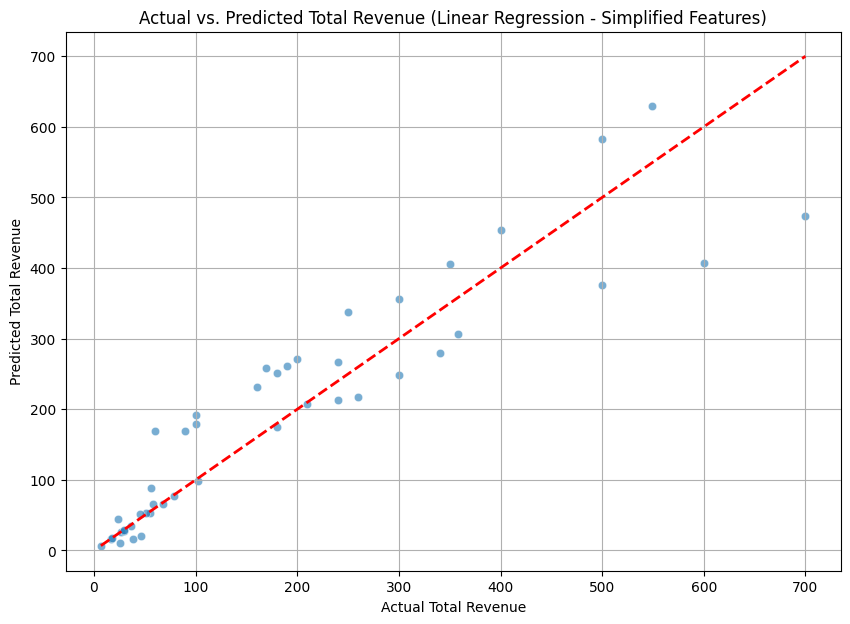

In [38]:
# Re-defining features (X) by excluding 'Product Name' related columns, 'Transaction ID', and 'Date'
# We can identify 'Product Name' columns by their prefix after one-hot encoding.
product_name_cols = [col for col in df_encoded.columns if col.startswith('Product Name_')]

X_simplified = df_encoded.drop(columns=['Total Revenue', 'Transaction ID', 'Date'] + product_name_cols)
y_simplified = df_encoded['Total Revenue']

# Split the data into training and testing sets again with the simplified features
X_train_simplified, X_test_simplified, y_train_simplified, y_test_simplified = train_test_split(X_simplified, y_simplified, test_size=0.2, random_state=42)

print(f"Shape of X_train_simplified: {X_train_simplified.shape}")
print(f"Shape of X_test_simplified: {X_test_simplified.shape}")

# Initialize and train the Linear Regression model with simplified features
linear_model_simplified = LinearRegression()
linear_model_simplified.fit(X_train_simplified, y_train_simplified)

# Make predictions on the test set
y_pred_simplified = linear_model_simplified.predict(X_test_simplified)

# Evaluate the simplified model
mae_simplified = mean_absolute_error(y_test_simplified, y_pred_simplified)
r2_simplified = r2_score(y_test_simplified, y_pred_simplified)

print(f"\nMean Absolute Error (MAE) with simplified features: {mae_simplified:.2f}")
print(f"R-squared (R2) Score with simplified features: {r2_simplified:.2f}")

# Plot Actual vs. Predicted Revenue for the simplified model
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test_simplified, y=y_pred_simplified, alpha=0.6)
plt.plot([y_test_simplified.min(), y_test_simplified.max()], [y_test_simplified.min(), y_test_simplified.max()], '--r', linewidth=2) # Ideal line
plt.title('Actual vs. Predicted Total Revenue (Linear Regression - Simplified Features)')
plt.xlabel('Actual Total Revenue')
plt.ylabel('Predicted Total Revenue')
plt.grid(True)
plt.show()

### Identifying Most Influential Features

For a linear regression model, the magnitude of the coefficients associated with each feature can indicate its importance in predicting the target variable. A larger absolute coefficient value suggests a stronger influence.

Let's extract and analyze the coefficients from our `linear_model_simplified` to understand which features are most impactful on 'Total Revenue'.

Most Influential Features (ranked by absolute coefficient):


,Feature,Coefficient,Absolute Coefficient
0,Product Category_Home Appliances,76.125166,76.125166
1,Product Category_Books,-70.306965,70.306965
2,Product Category_Electronics,62.973058,62.973058
3,Units Sold,38.070064,38.070064
4,Product Category_Sports,25.536082,25.536082
5,Payment Method_PayPal,-19.291002,19.291002
6,Region_Europe,-19.291002,19.291002
7,Region_North America,-7.333906,7.333906
8,Payment Method_Debit Card,1.088826,1.088826
9,Product Category_Clothing,1.088826,1.088826


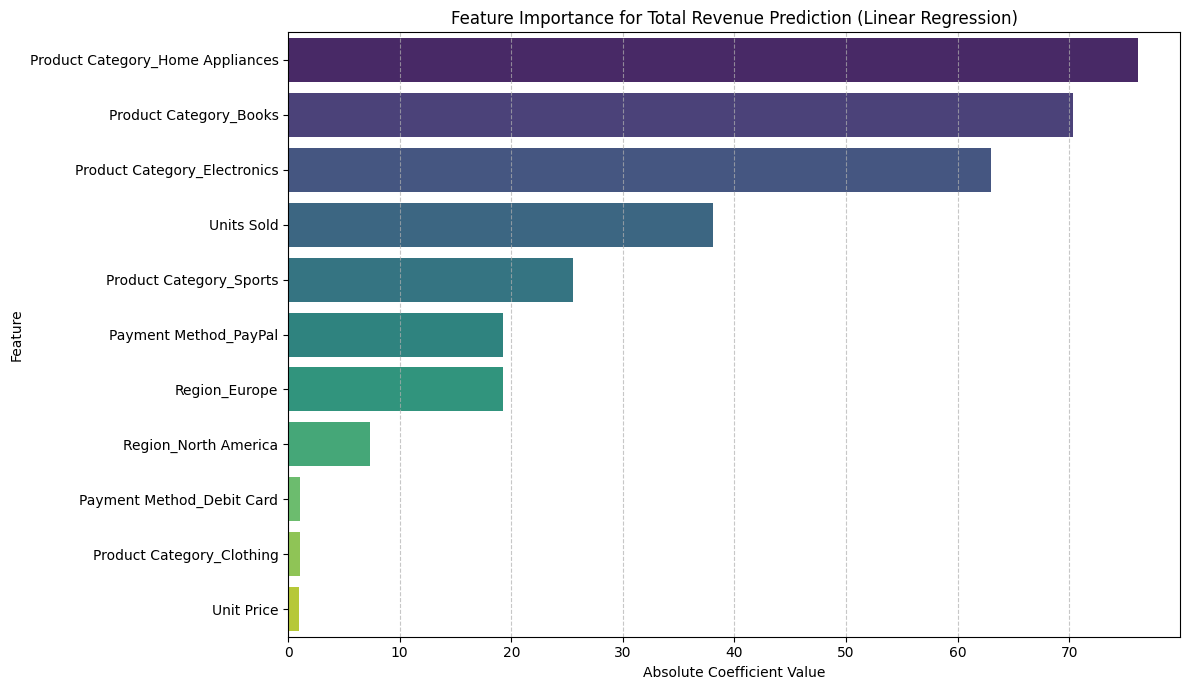

In [39]:
# Get the coefficients from the simplified linear model
coefficients = linear_model_simplified.coef_

# Get the feature names from the X_train_simplified DataFrame
feature_names = X_train_simplified.columns

# Create a DataFrame to store feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Calculate absolute coefficients for ranking
feature_importance['Absolute Coefficient'] = abs(feature_importance['Coefficient'])

# Sort by absolute coefficient in descending order
feature_importance = feature_importance.sort_values(by='Absolute Coefficient', ascending=False).reset_index(drop=True)

print("Most Influential Features (ranked by absolute coefficient):")
display(feature_importance)

# Visualize feature importance
plt.figure(figsize=(12, 7))
sns.barplot(x='Absolute Coefficient', y='Feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance for Total Revenue Prediction (Linear Regression)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Distribution of Numerical Features

Let's visualize the distributions of the numerical features (`Units Sold`, `Unit Price`, and `Total Revenue`) from the `df_cleaned` DataFrame to understand their spread and identify any skewness or unusual patterns.

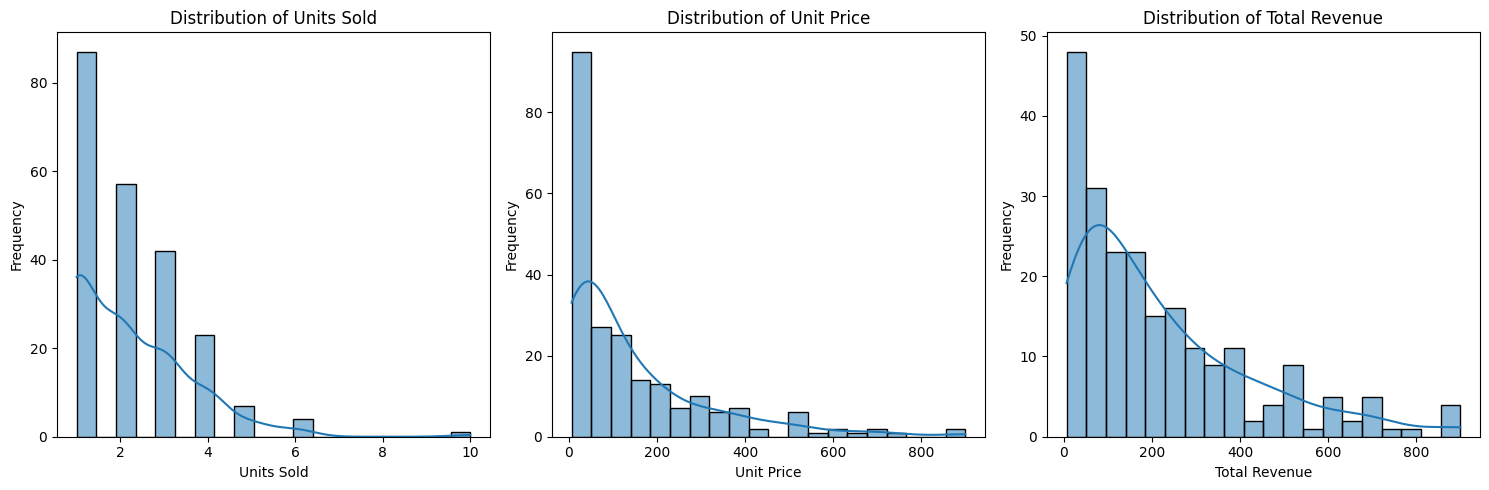

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of numerical columns to visualize (already defined as 'numerical_cols')
# numerical_cols = ['Units Sold', 'Unit Price', 'Total Revenue']

plt.figure(figsize=(15, 5))

for i, col in enumerate(numerical_cols):
    plt.subplot(1, len(numerical_cols), i + 1)
    sns.histplot(df_cleaned[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## Training and Comparing Multiple Predictive Models

We will now train several different regression models to predict 'Total Revenue' using the simplified feature set (`X_simplified`). The goal is to compare their performance against the Linear Regression model and identify the best-performing model.

In [42]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Initialize models
models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# Store results
results = {"Linear Regression Simplified": {'MAE': mae_simplified, 'R2': r2_simplified}}

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train_simplified, y_train_simplified)
    y_pred = model.predict(X_test_simplified)
    mae = mean_absolute_error(y_test_simplified, y_pred)
    r2 = r2_score(y_test_simplified, y_pred)
    results[name] = {'MAE': mae, 'R2': r2}

# Display results
results_df = pd.DataFrame(results).T.sort_values(by='R2', ascending=False)
print("\nModel Performance Comparison (Simplified Features):")
display(results_df)


Model Performance Comparison (Simplified Features):


,MAE,R2
Gradient Boosting,8.135871,0.994570
Random Forest,6.818504,0.994497
Decision Tree,9.144222,0.982131
Linear Regression Simplified,46.831380,0.846810


### Visualizing Model Performance

To better understand the comparison, let's visualize the R-squared and MAE for each model.

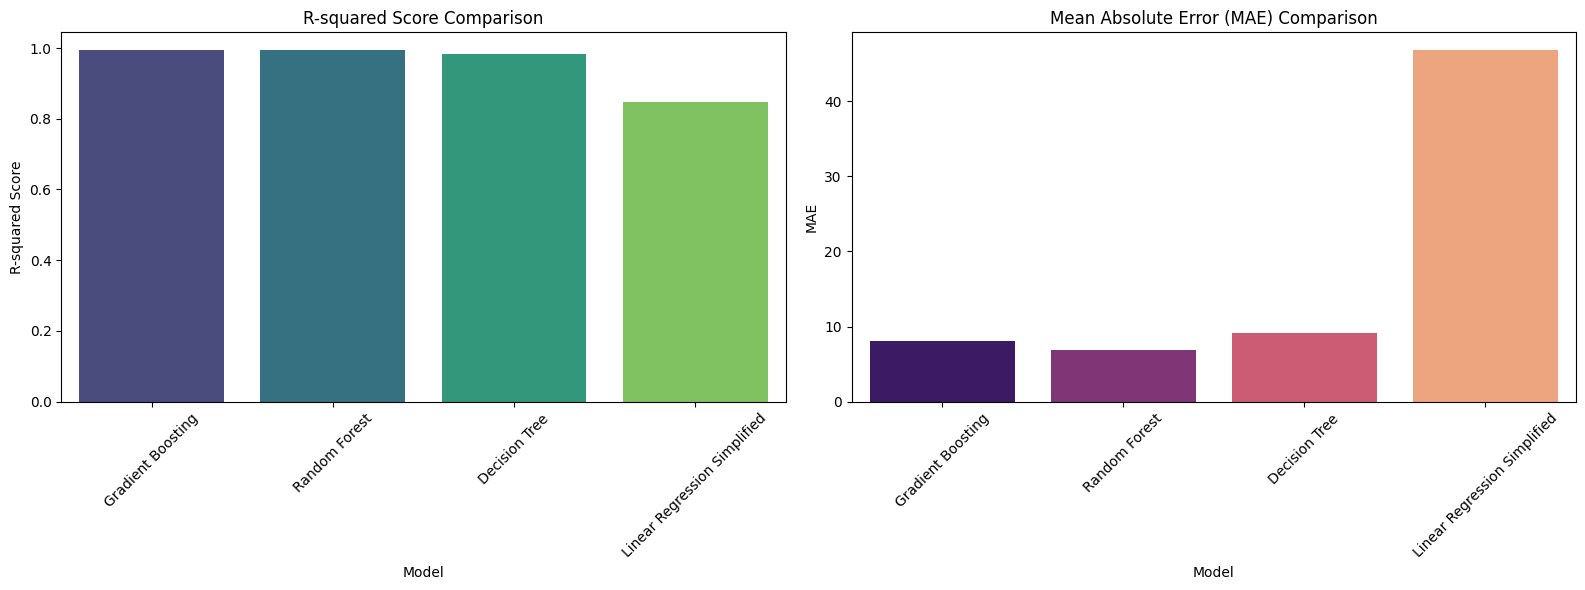

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot R-squared
sns.barplot(x=results_df.index, y='R2', data=results_df, ax=axes[0], palette='viridis')
axes[0].set_title('R-squared Score Comparison')
axes[0].set_ylabel('R-squared Score')
axes[0].set_xlabel('Model')
axes[0].tick_params(axis='x', rotation=45)

# Plot MAE
sns.barplot(x=results_df.index, y='MAE', data=results_df, ax=axes[1], palette='magma')
axes[1].set_title('Mean Absolute Error (MAE) Comparison')
axes[1].set_ylabel('MAE')
axes[1].set_xlabel('Model')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### Correlation Heatmap of All Numerical Features (Simplified Model Features)

Let's generate a correlation heatmap for all the numerical features included in `X_simplified`. This includes the core numerical features as well as the one-hot encoded categorical features (excluding `Product Name`). This visualization will help us understand the relationships and potential multicollinearity among these influential features.

Correlation Matrix of Features in Simplified Model:


,Units Sold,Unit Price,Product Category_Books,Product Category_Clothing,Product Category_Electronics,Product Category_Home Appliances,Product Category_Sports,Region_Europe,Region_North America,Payment Method_Debit Card,Payment Method_PayPal
Units Sold,1.000000,-0.426520,0.223605,0.493594,-0.139584,-0.257778,0.018577,-0.499863,0.089845,0.493594,-0.499863
Unit Price,-0.426520,1.000000,-0.350765,-0.210122,0.381291,0.336474,0.144728,0.080784,-0.026661,-0.210122,0.080784
Product Category_Books,0.223605,-0.350765,1.000000,-0.220994,-0.171656,-0.210806,-0.214218,-0.343760,0.720418,-0.220994,-0.343760
Product Category_Clothing,0.493594,-0.210122,-0.220994,1.000000,-0.171656,-0.210806,-0.214218,-0.343760,-0.306759,1.000000,-0.343760
Product Category_Electronics,-0.139584,0.381291,-0.171656,-0.171656,1.000000,-0.163742,-0.166393,-0.267014,0.559581,-0.171656,-0.267014
Product Category_Home Appliances,-0.257778,0.336474,-0.210806,-0.210806,-0.163742,1.000000,-0.204342,0.613236,-0.292616,-0.210806,0.613236
Product Category_Sports,0.018577,0.144728,-0.214218,-0.214218,-0.166393,-0.204342,1.000000,-0.333219,-0.297353,-0.214218,-0.333219
Region_Europe,-0.499863,0.080784,-0.343760,-0.343760,-0.267014,0.613236,-0.333219,1.000000,-0.477167,-0.343760,1.000000
Region_North America,0.089845,-0.026661,0.720418,-0.306759,0.559581,-0.292616,-0.297353,-0.477167,1.000000,-0.306759,-0.477167
Payment Method_Debit Card,0.493594,-0.210122,-0.220994,1.000000,-0.171656,-0.210806,-0.214218,-0.343760,-0.306759,1.000000,-0.343760


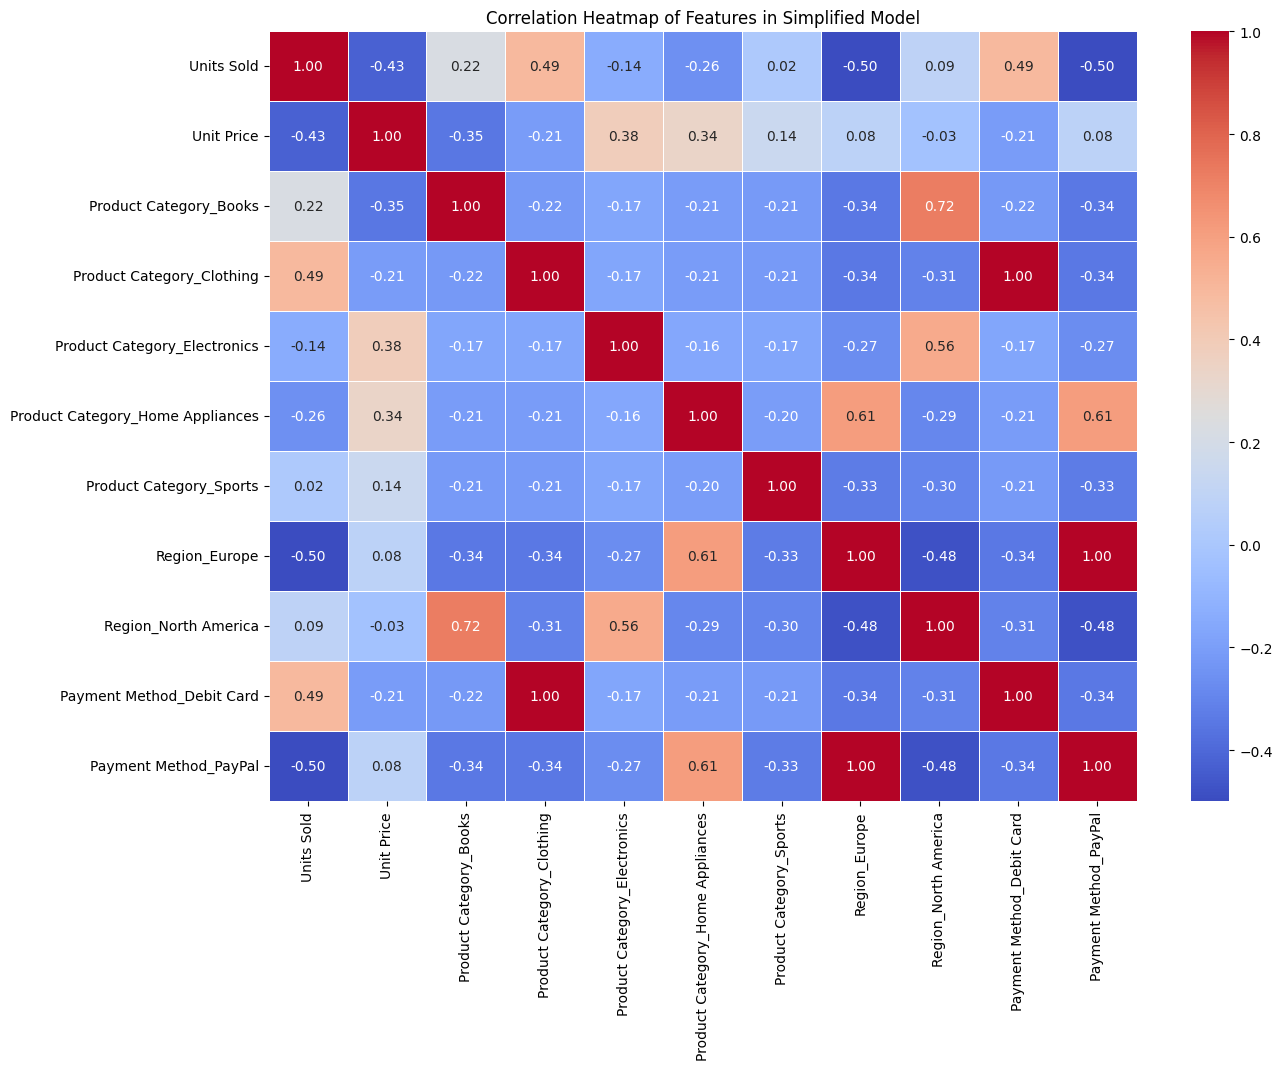

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for the features in X_simplified
correlation_matrix_simplified = X_simplified.corr()

print("Correlation Matrix of Features in Simplified Model:")
display(correlation_matrix_simplified)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix_simplified, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Features in Simplified Model')
plt.show()

### Feature Importance from Random Forest Model

Let's examine the feature importances derived from the Random Forest model, which was one of the best-performing models. This will show us which features it considered most important for predicting 'Total Revenue'.

Feature Importances from Random Forest Model:


,Feature,Importance
0,Unit Price,0.847374
1,Units Sold,0.134687
2,Product Category_Sports,0.004471
3,Region_North America,0.003174
4,Region_Europe,0.002677
5,Product Category_Electronics,0.002172
6,Payment Method_PayPal,0.001941
7,Product Category_Home Appliances,0.001210
8,Product Category_Clothing,0.001066
9,Payment Method_Debit Card,0.001034


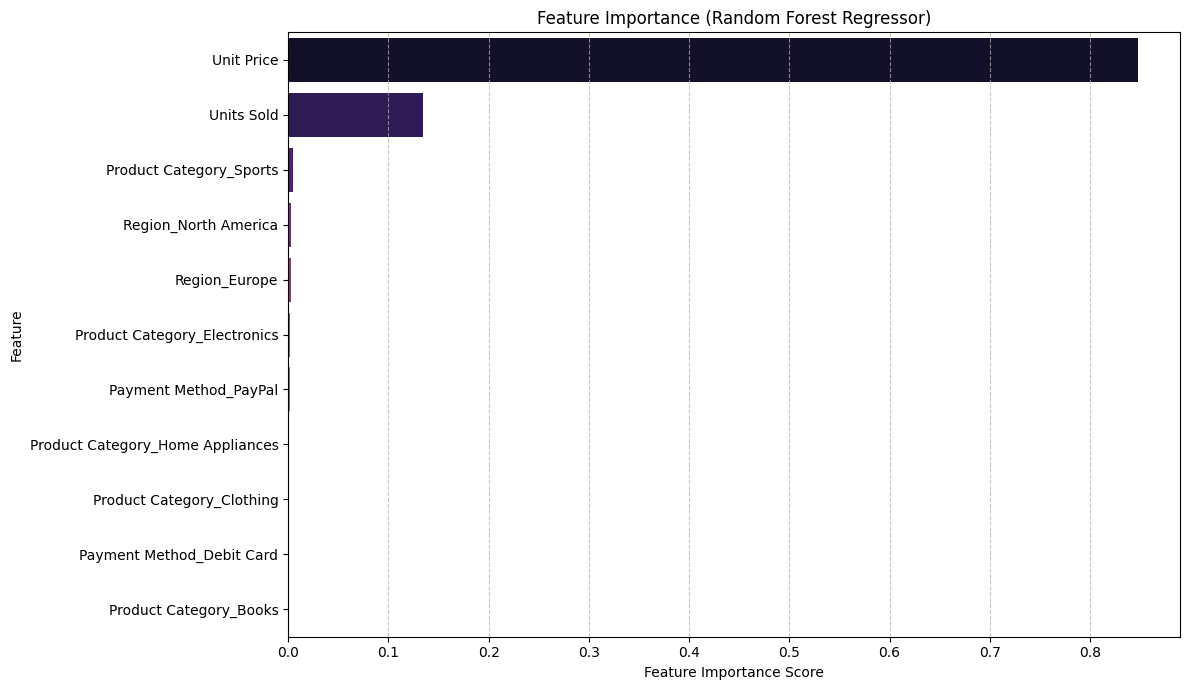

In [44]:
# Get the trained Random Forest model
rf_model = models["Random Forest"]

# Get feature importances
rf_feature_importances = rf_model.feature_importances_

# Get feature names from the simplified training data
feature_names_simplified = X_train_simplified.columns

# Create a DataFrame for feature importance
rf_importance_df = pd.DataFrame({
    'Feature': feature_names_simplified,
    'Importance': rf_feature_importances
})

# Sort by importance in descending order
rf_importance_df = rf_importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("Feature Importances from Random Forest Model:")
display(rf_importance_df)

# Visualize feature importance
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=rf_importance_df, palette='magma')
plt.title('Feature Importance (Random Forest Regressor)')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Scatter Plot: Unit Price vs. Total Revenue

Let's visualize the direct relationship between 'Unit Price' and 'Total Revenue' using a scatter plot. This will help us confirm the strong positive correlation observed earlier.

### Model Performance Comparison (R-squared and MAE)

As previously shown, bar plots are an effective way to compare the single R-squared and Mean Absolute Error (MAE) values obtained for each regression model.

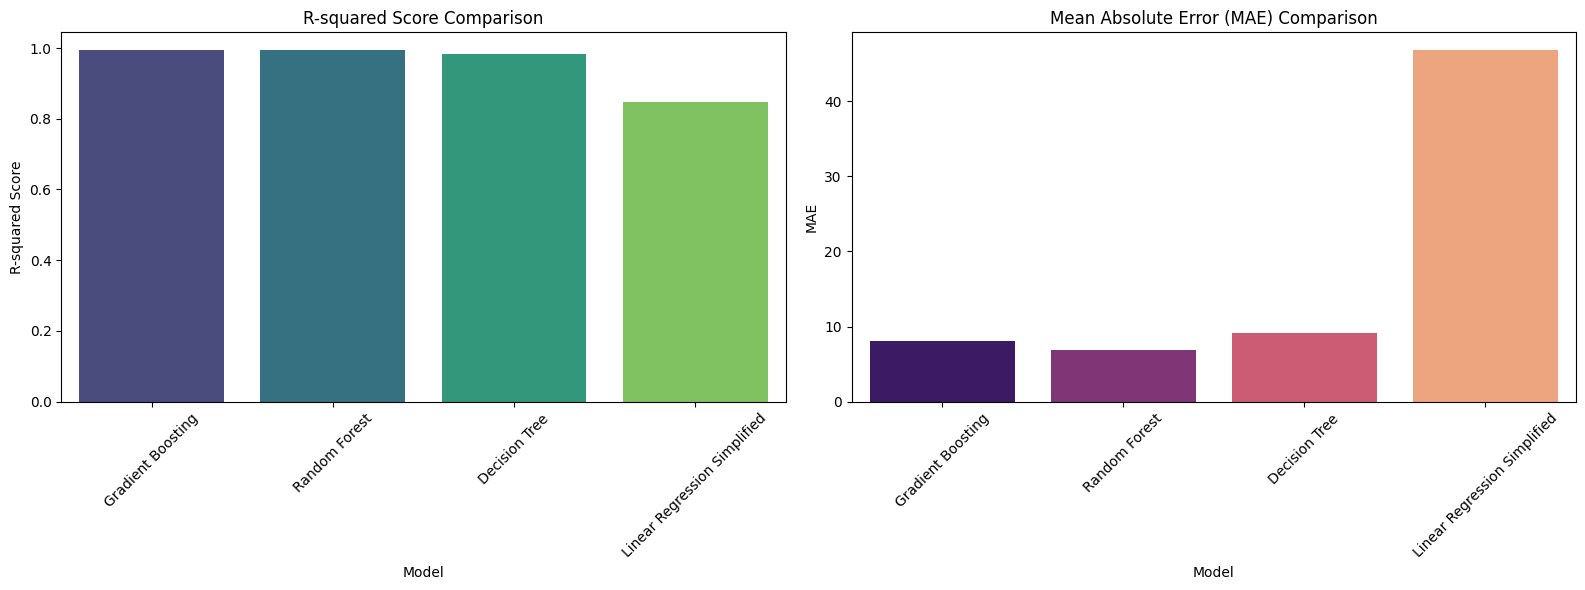

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot R-squared
sns.barplot(x=results_df.index, y='R2', data=results_df, ax=axes[0], palette='viridis')
axes[0].set_title('R-squared Score Comparison')
axes[0].set_ylabel('R-squared Score')
axes[0].set_xlabel('Model')
axes[0].tick_params(axis='x', rotation=45)

# Plot MAE
sns.barplot(x=results_df.index, y='MAE', data=results_df, ax=axes[1], palette='magma')
axes[1].set_title('Mean Absolute Error (MAE) Comparison')
axes[1].set_ylabel('MAE')
axes[1].set_xlabel('Model')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Visualizing Actual vs. Predicted Revenue for All Models

To further compare the models, let's plot the actual `Total Revenue` against the predicted `Total Revenue` for each of our trained models on the test set. A perfect model would have all points lying on the red diagonal line.

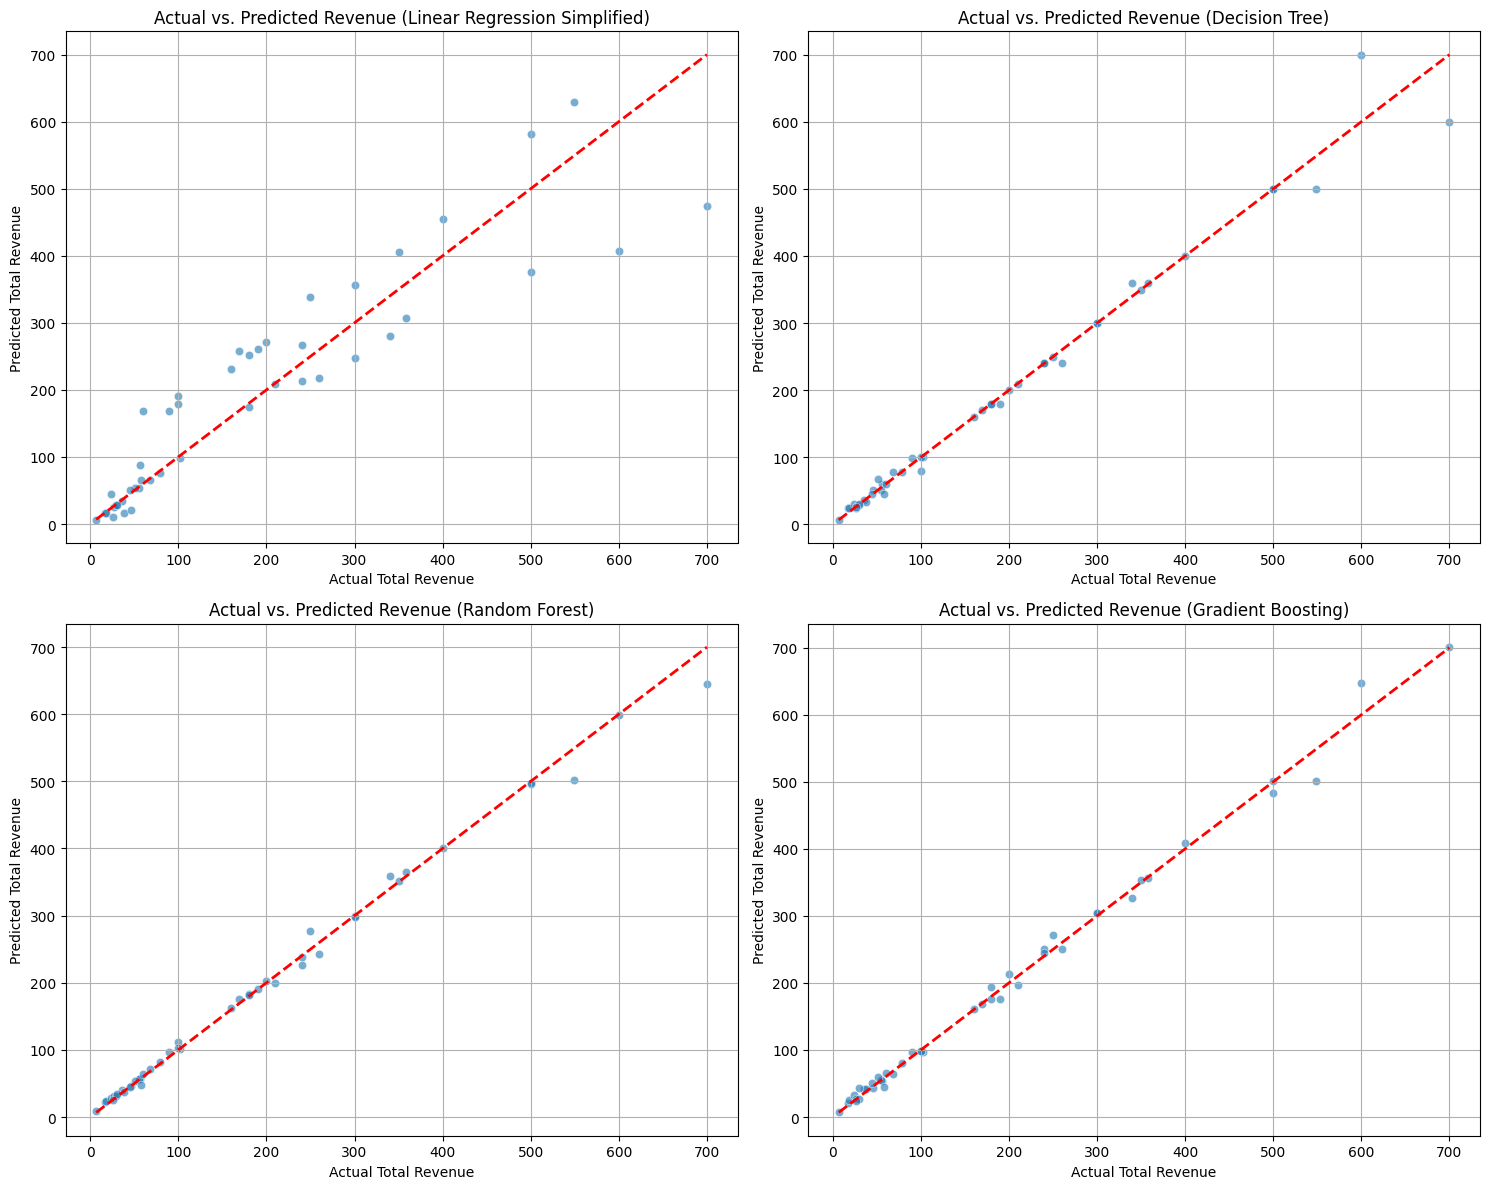

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare predictions for all models
all_models = {
    "Linear Regression Simplified": linear_model_simplified,
    "Decision Tree": models["Decision Tree"],
    "Random Forest": models["Random Forest"],
    "Gradient Boosting": models["Gradient Boosting"]
}

# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten() # Flatten the 2x2 array of axes for easier iteration

for i, (name, model) in enumerate(all_models.items()):
    y_pred = model.predict(X_test_simplified)

    ax = axes[i]
    sns.scatterplot(x=y_test_simplified, y=y_pred, alpha=0.6, ax=ax)
    ax.plot([y_test_simplified.min(), y_test_simplified.max()],
            [y_test_simplified.min(), y_test_simplified.max()], '--r', linewidth=2) # Ideal line
    ax.set_title(f'Actual vs. Predicted Revenue ({name})')
    ax.set_xlabel('Actual Total Revenue')
    ax.set_ylabel('Predicted Total Revenue')
    ax.grid(True)

plt.tight_layout()
plt.show()

### Residual Analysis for the Best-Performing Model (Random Forest)

Residuals are the differences between the actual values and the predicted values. Analyzing residuals helps us understand the errors made by the model. A good model should have residuals that are randomly distributed around zero, with no discernible patterns.

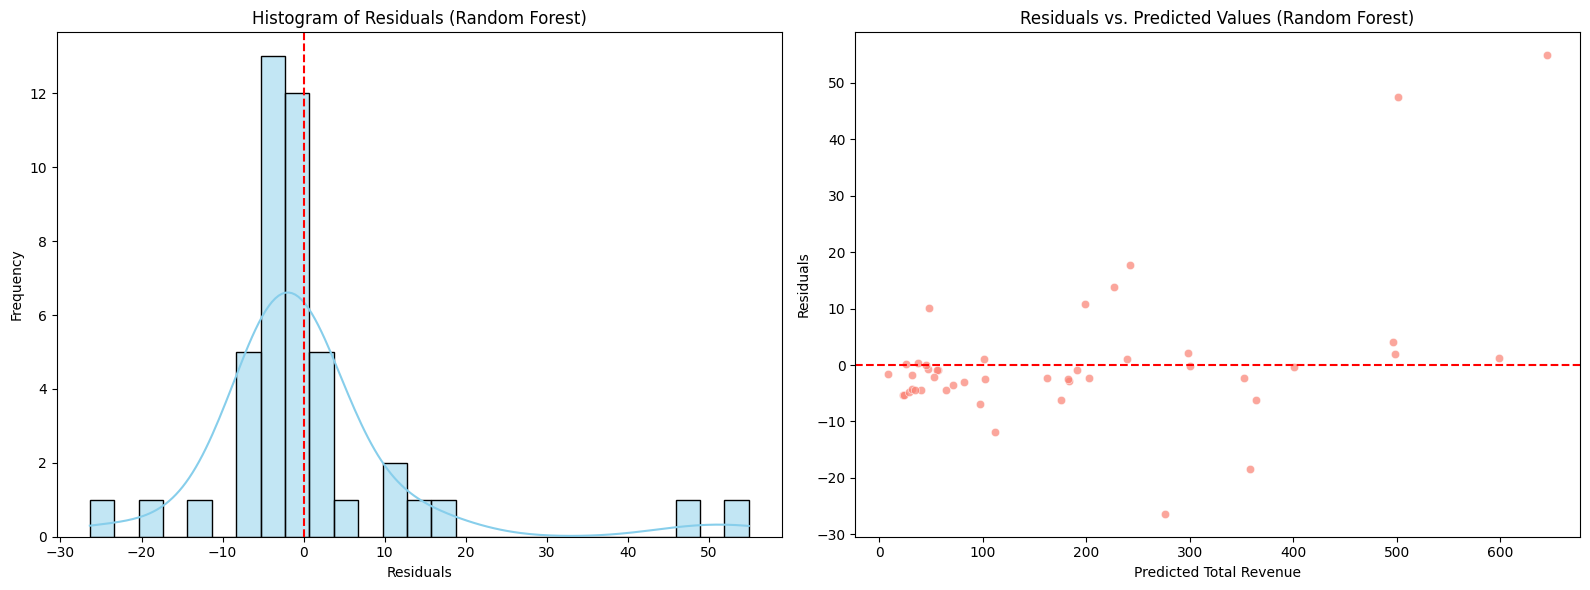

Summary Statistics of Residuals:


,Total Revenue
count,45.000000
mean,0.603300
std,13.091731
min,-26.373100
25%,-4.352400
50%,-1.742700
75%,1.051100
max,54.901300


In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get the best-performing model (Random Forest)
rf_model = models["Random Forest"]

# Make predictions on the simplified test set
y_pred_rf = rf_model.predict(X_test_simplified)

# Calculate residuals
residuals_rf = y_test_simplified - y_pred_rf

# Plotting residuals
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram of Residuals
sns.histplot(residuals_rf, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Histogram of Residuals (Random Forest)')
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Frequency')
axes[0].axvline(0, color='red', linestyle='--') # Line at zero

# Scatter Plot of Residuals vs. Predicted Values
sns.scatterplot(x=y_pred_rf, y=residuals_rf, ax=axes[1], alpha=0.7, color='salmon')
axes[1].set_title('Residuals vs. Predicted Values (Random Forest)')
axes[1].set_xlabel('Predicted Total Revenue')
axes[1].set_ylabel('Residuals')
axes[1].axhline(0, color='red', linestyle='--') # Line at zero

plt.tight_layout()
plt.show()

print("Summary Statistics of Residuals:")
display(pd.Series(residuals_rf).describe())

### Comprehensive Model Performance Comparison

To thoroughly evaluate and compare the models, we will calculate several key regression metrics: Mean Absolute Error (MAE), Mean Absolute Percentage Error (MAPE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared. These metrics provide different perspectives on the models' predictive accuracy and error distribution.

In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def mean_absolute_percentage_error(y_true, y_pred):
    # Avoid division by zero, replace 0s in y_true with a small epsilon if present
    # Assuming y_true 'Total Revenue' is always positive or at least non-zero for meaningful MAPE.
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Prepare all models for comprehensive evaluation
all_models_eval = {
    "Linear Regression Simplified": linear_model_simplified,
    "Decision Tree": models["Decision Tree"],
    "Random Forest": models["Random Forest"],
    "Gradient Boosting": models["Gradient Boosting"]
}

# Dictionary to store all evaluation results
all_results = {}

# Evaluate each model
for name, model in all_models_eval.items():
    y_pred = model.predict(X_test_simplified)

    mae = mean_absolute_error(y_test_simplified, y_pred)
    mse = mean_squared_error(y_test_simplified, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_simplified, y_pred)

    # Calculate MAPE, handle potential division by zero if y_true can be zero
    # For 'Total Revenue', assuming values are generally positive and non-zero.
    mape = mean_absolute_percentage_error(y_test_simplified, y_pred)

    all_results[name] = {
        'MAE': mae,
        'MAPE': mape,
        'MSE': mse,
        'RMSE': rmse,
        'R-squared': r2
    }

# Convert results to a DataFrame for easy viewing and comparison
all_results_df = pd.DataFrame(all_results).T.sort_values(by='R-squared', ascending=False)

print("\nComprehensive Model Performance Comparison:")
display(all_results_df)


Comprehensive Model Performance Comparison:


,MAE,MAPE,MSE,RMSE,R-squared
Gradient Boosting,8.135871,8.398299,165.716923,12.873109,0.994570
Random Forest,6.818504,6.371114,167.948641,12.959500,0.994497
Decision Tree,9.144222,6.823343,545.369149,23.353140,0.982131
Linear Regression Simplified,46.831380,29.766389,4675.292119,68.376108,0.846810


### Visualizing Comprehensive Model Performance

Let's visualize these metrics to provide a clear and intuitive comparison across all models.

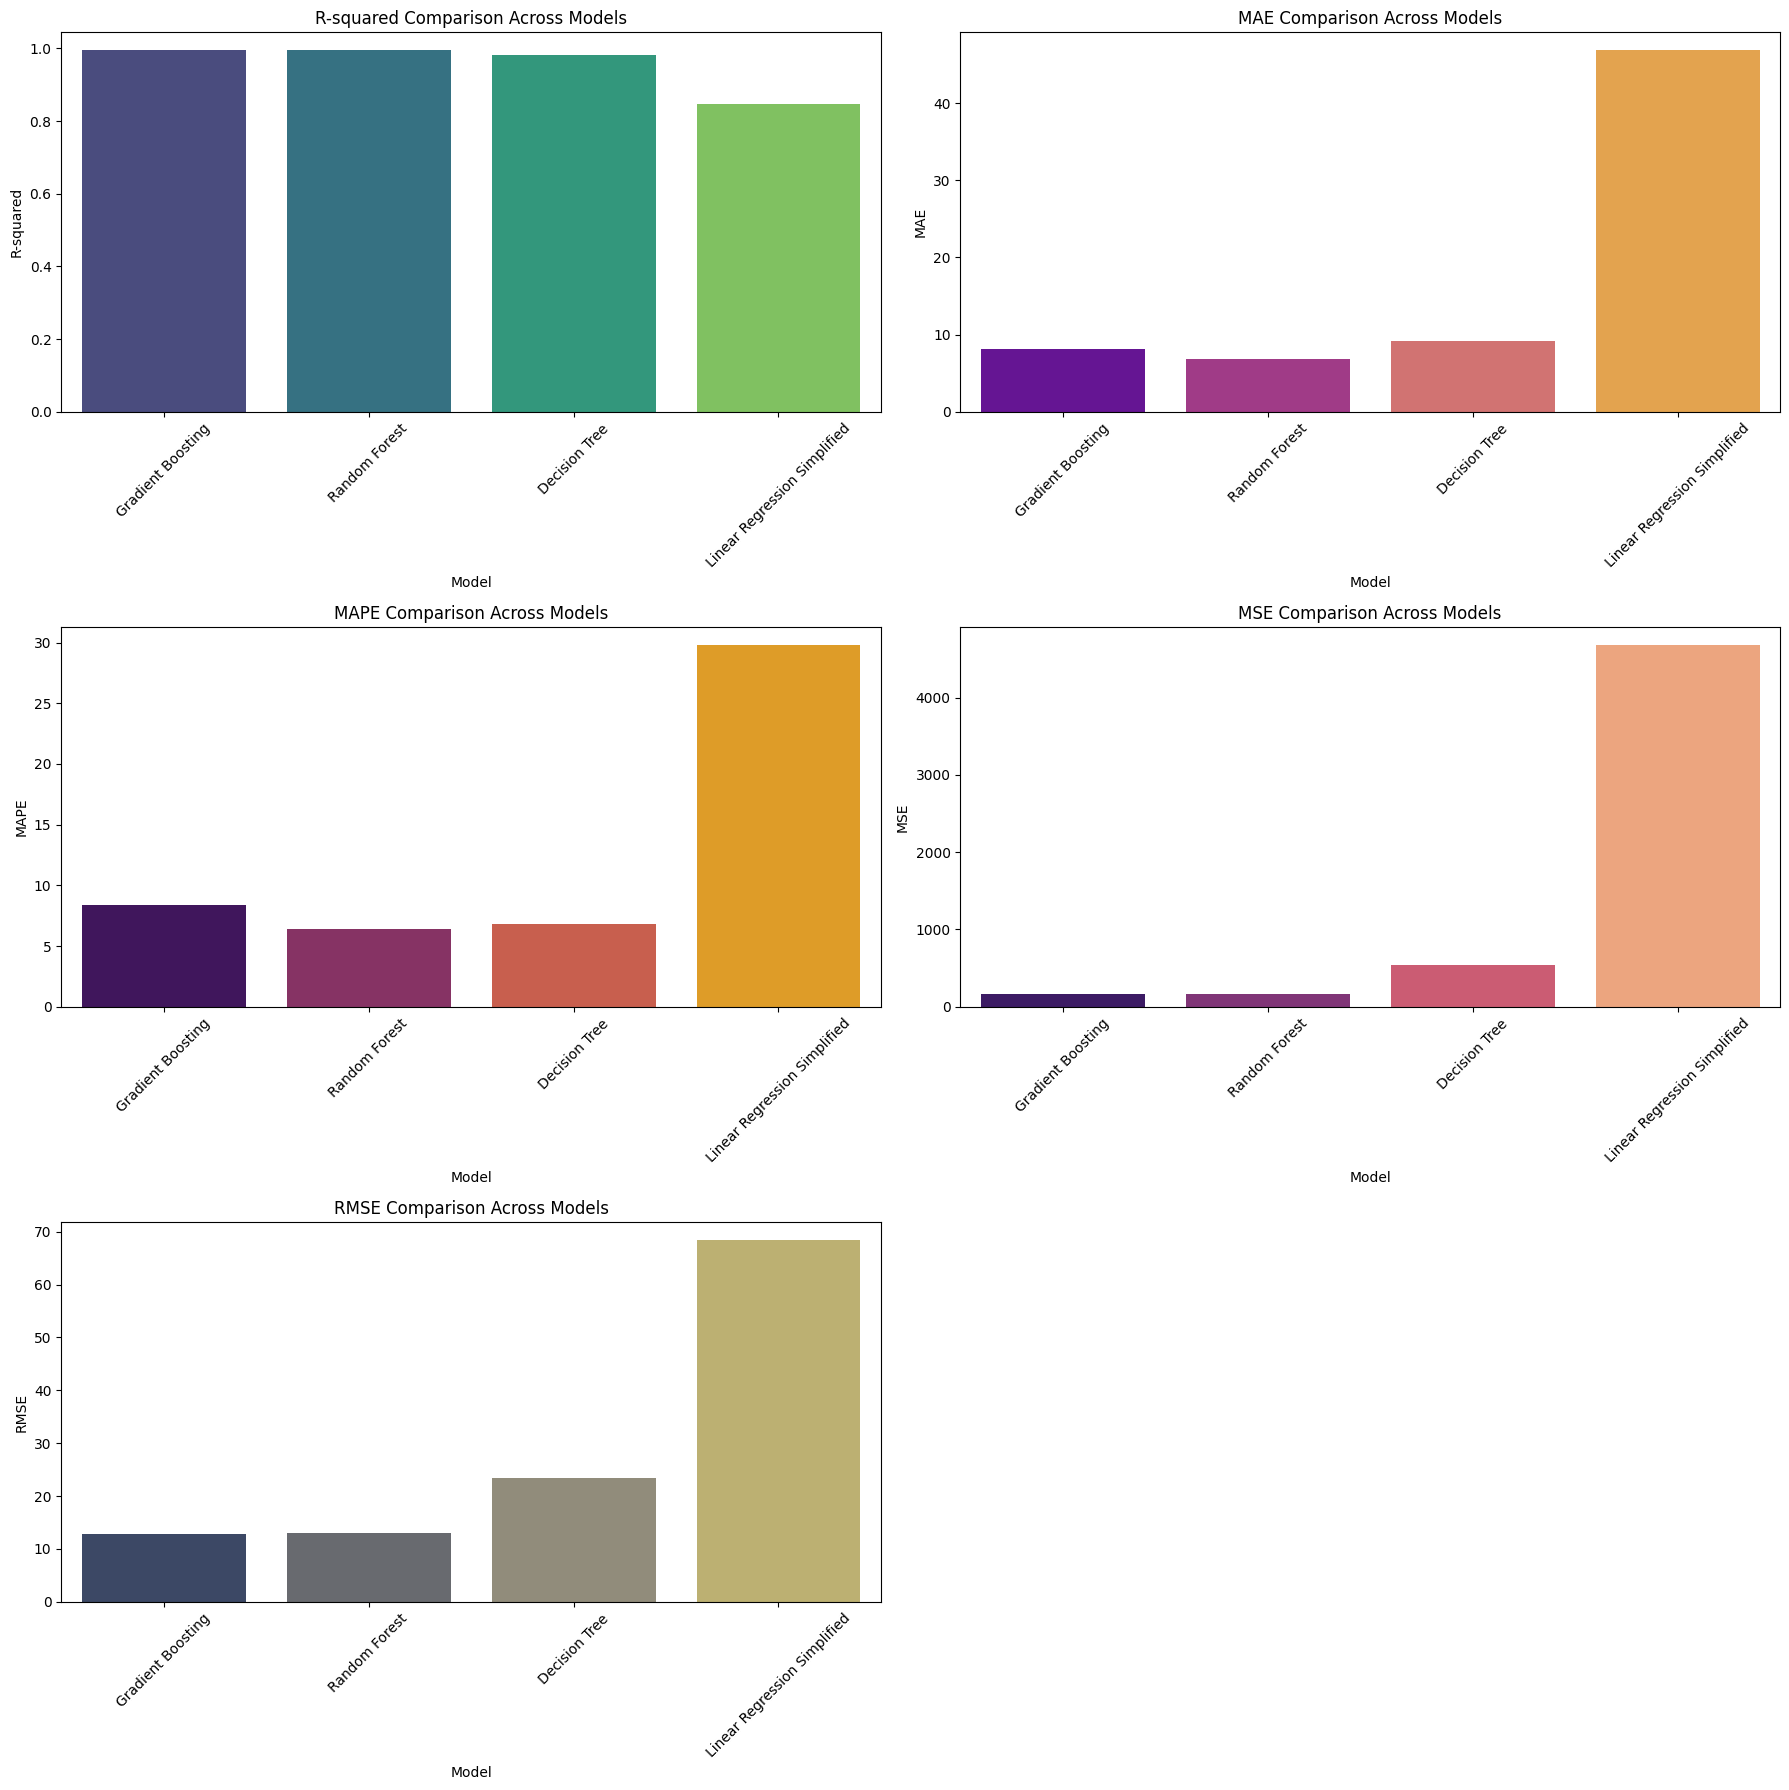

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots for each metric
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes = axes.flatten()

metrics_to_plot = ['R-squared', 'MAE', 'MAPE', 'MSE', 'RMSE']
palettes = ['viridis', 'plasma', 'inferno', 'magma', 'cividis']

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(x=all_results_df.index, y=metric, data=all_results_df, ax=axes[i], palette=palettes[i])
    axes[i].set_title(f'{metric} Comparison Across Models')
    axes[i].set_xlabel('Model')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=45)

# Remove the last empty subplot if there's an odd number of metrics
if len(metrics_to_plot) % 2 != 0:
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

### Summary Table: Top Two Model Comparison

Based on our comprehensive evaluation, Gradient Boosting and Random Forest are the best-performing models. Here's a direct comparison of their key metrics.

In [52]:
# Select only the top two models (Gradient Boosting and Random Forest) from the all_results_df
top_two_models_summary = all_results_df.loc[['Gradient Boosting', 'Random Forest']]

print("Summary Comparison of Top Two Models:")
display(top_two_models_summary)

Summary Comparison of Top Two Models:


,MAE,MAPE,MSE,RMSE,R-squared
Gradient Boosting,8.135871,8.398299,165.716923,12.873109,0.994570
Random Forest,6.818504,6.371114,167.948641,12.959500,0.994497


### Model Optimization: Hyperparameter Tuning for Random Forest

To further optimize our best-performing models, we'll perform hyperparameter tuning. Hyperparameters are parameters whose values are set before the learning process begins. Finding the optimal combination of these parameters can significantly improve model performance.

We will use `GridSearchCV` for the Random Forest Regressor to systematically search for the best combination of hyperparameters. This involves:
1. Defining a parameter grid with different values for key hyperparameters.
2. Running `GridSearchCV` with cross-validation to evaluate each combination.
3. Identifying the best parameters and the resulting best model.

In [53]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Define the parameter grid for Random Forest
# These ranges can be adjusted based on initial intuition or broader search if needed
param_grid_rf = {
    'n_estimators': [50, 100, 200], # Number of trees in the forest
    'max_depth': [None, 10, 20],   # Maximum depth of the tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]    # Minimum number of samples required to be at a leaf node
}

# Initialize the Random Forest Regressor
rf = RandomForestRegressor(random_state=42)

# Initialize GridSearchCV
# n_jobs=-1 uses all available processors
# cv=5 means 5-fold cross-validation
grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=5, n_jobs=-1, verbose=2, scoring='r2')

print("Starting GridSearchCV for Random Forest...")
# Fit GridSearchCV to the training data (simplified features)
grid_search_rf.fit(X_train_simplified, y_train_simplified)

print("GridSearchCV complete.")

# Get the best parameters and the best score
best_params_rf = grid_search_rf.best_params_
best_score_rf = grid_search_rf.best_score_
best_estimator_rf = grid_search_rf.best_estimator_

print(f"\nBest parameters for Random Forest: {best_params_rf}")
print(f"Best cross-validation R-squared score: {best_score_rf:.4f}")

# Evaluate the best estimator on the test set
y_pred_tuned_rf = best_estimator_rf.predict(X_test_simplified)
final_r2_tuned_rf = r2_score(y_test_simplified, y_pred_tuned_rf)
final_mae_tuned_rf = mean_absolute_error(y_test_simplified, y_pred_tuned_rf)

print(f"Test Set R-squared (tuned Random Forest): {final_r2_tuned_rf:.4f}")
print(f"Test Set MAE (tuned Random Forest): {final_mae_tuned_rf:.4f}")

Starting GridSearchCV for Random Forest...
Fitting 5 folds for each of 81 candidates, totalling 405 fits
GridSearchCV complete.

Best parameters for Random Forest: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validation R-squared score: 0.9619
Test Set R-squared (tuned Random Forest): 0.9944
Test Set MAE (tuned Random Forest): 7.1479


In [54]:
# Update the all_results dictionary with the tuned Random Forest's performance
all_results['Random Forest Tuned'] = {
    'MAE': final_mae_tuned_rf,
    'MAPE': mean_absolute_percentage_error(y_test_simplified, y_pred_tuned_rf),
    'MSE': mean_squared_error(y_test_simplified, y_pred_tuned_rf),
    'RMSE': np.sqrt(mean_squared_error(y_test_simplified, y_pred_tuned_rf)),
    'R-squared': final_r2_tuned_rf
}

# Recreate the DataFrame for easy viewing and comparison
all_results_df = pd.DataFrame(all_results).T.sort_values(by='R-squared', ascending=False)

print("\nUpdated Comprehensive Model Performance Comparison (including Tuned Random Forest):")
display(all_results_df)


Updated Comprehensive Model Performance Comparison (including Tuned Random Forest):


,MAE,MAPE,MSE,RMSE,R-squared
Gradient Boosting,8.135871,8.398299,165.716923,12.873109,0.994570
Random Forest,6.818504,6.371114,167.948641,12.959500,0.994497
Random Forest Tuned,7.147889,6.522359,170.329210,13.051023,0.994419
Decision Tree,9.144222,6.823343,545.369149,23.353140,0.982131
Linear Regression Simplified,46.831380,29.766389,4675.292119,68.376108,0.846810


### Visualizing Comprehensive Model Performance (Updated with Tuned Random Forest)

Let's re-visualize the metrics to include the tuned Random Forest model and provide a clear and intuitive comparison across all models.

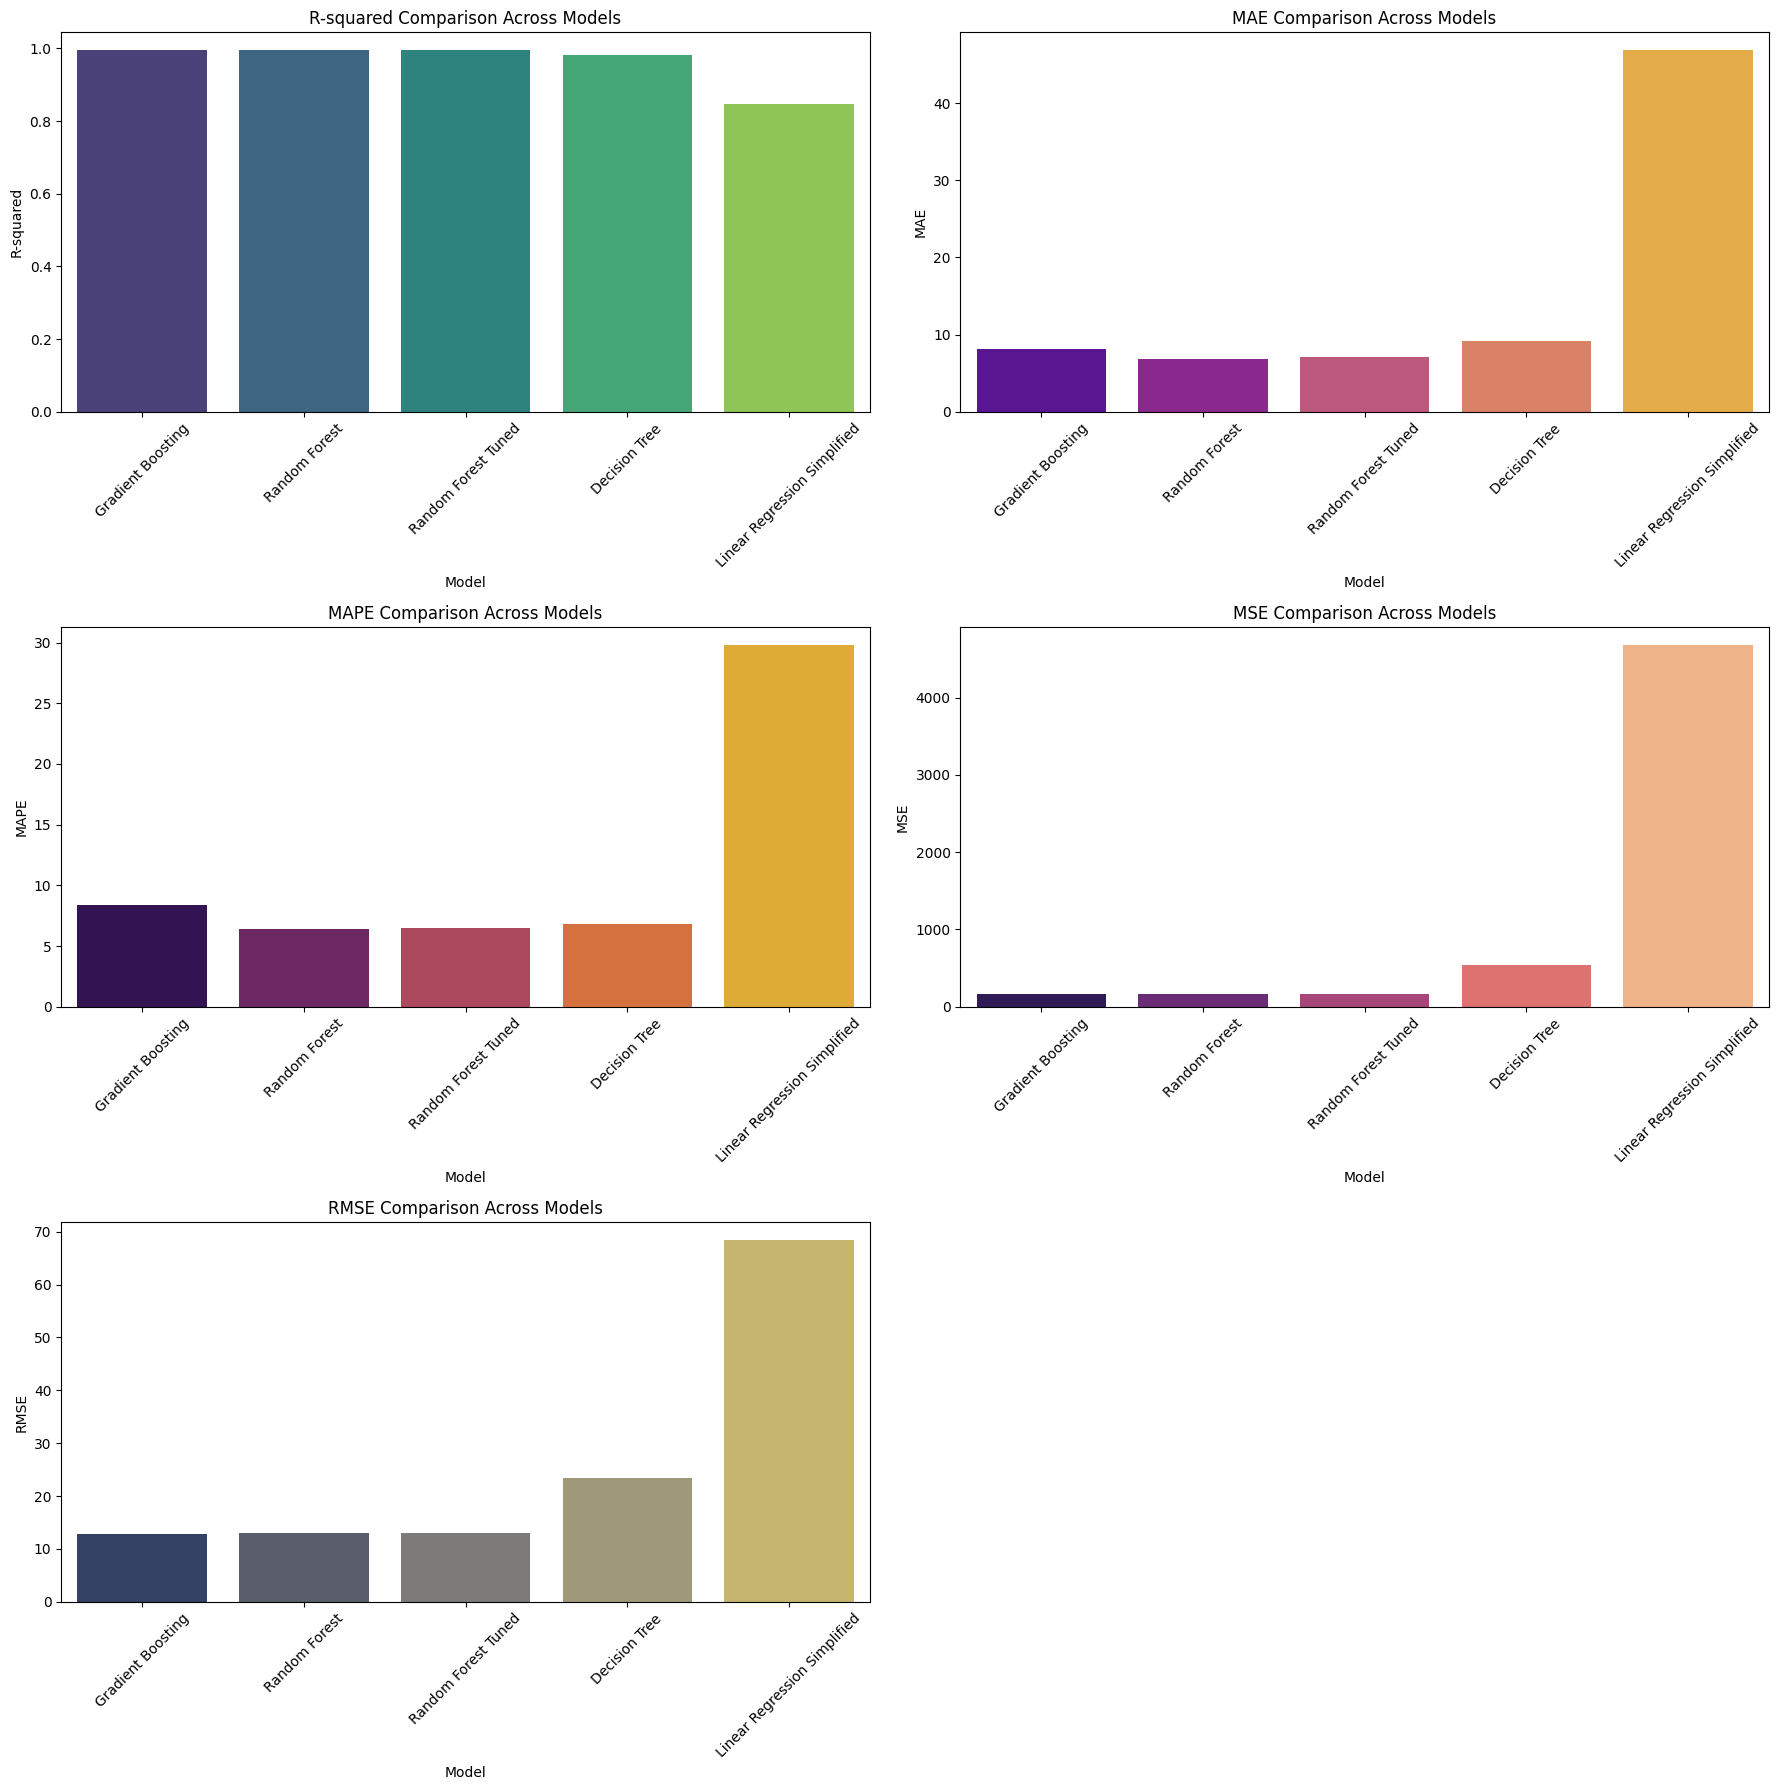

In [55]:
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes = axes.flatten()

metrics_to_plot = ['R-squared', 'MAE', 'MAPE', 'MSE', 'RMSE']
palettes = ['viridis', 'plasma', 'inferno', 'magma', 'cividis']

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(x=all_results_df.index, y=metric, data=all_results_df, ax=axes[i], palette=palettes[i])
    axes[i].set_title(f'{metric} Comparison Across Models')
    axes[i].set_xlabel('Model')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=45)

# Remove the last empty subplot if there's an odd number of metrics
if len(metrics_to_plot) % 2 != 0:
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

## Business Insights and Recommendations

Based on our comprehensive analysis of the online sales data, we've uncovered several key insights that can inform business strategy and drive growth. Here are the main findings and actionable recommendations:

### 1. Significant Impact of Outliers

**Insight:** We identified 19 outliers in 'Total Revenue' (primarily in 'Electronics'), which accounted for a **39.71% decrease** in total revenue when removed. The 'Electronics' category alone contributed **67.74%** of its total revenue from outlier sales, highlighting the presence of high-value transactions or potentially unusual events.

**Recommendation:**
*   **Investigate High-Value Transactions:** Analyze the specific characteristics of these outlier sales. Are they bulk purchases, enterprise clients, or premium products? Understanding their nature can help in dedicated marketing or sales strategies.
*   **Consider Separate Forecasting:** For categories heavily influenced by outliers (like Electronics), consider developing separate forecasting models or employing robust models less sensitive to extreme values. This can provide a more stable prediction for regular sales, while outlier potential is managed distinctly.

### 2. Key Revenue Drivers

**Insight:**
*   **Strong Correlation with Unit Price:** `Unit Price` shows a very strong positive correlation (0.84) with `Total Revenue`, indicating that higher-priced items significantly contribute to overall revenue.
*   **Product Categories Dominate:** `Product Category_Home Appliances`, `Product Category_Books`, `Product Category_Electronics`, and `Units Sold` were identified as the most influential features in predicting 'Total Revenue' by our simplified linear model.
*   **Top Electronics Products:** Products like 'Sony WH-1000XM4 Headphones', 'Google Pixel 6 Pro', and 'Nintendo Switch' were identified as top revenue generators within the 'Electronics' category.

**Recommendation:**
*   **Premium Product Focus:** Continue to promote and strategically price higher-value items. Explore opportunities to introduce more premium products or bundles that can boost `Unit Price` and thus `Total Revenue`.
*   **Category-Specific Strategies:** Tailor marketing efforts and inventory management to the high-impact product categories. For instance, `Home Appliances` and `Electronics` should receive priority in terms of promotion and stock.
*   **Optimize Inventory for Top Products:** Ensure consistent availability and aggressive marketing for the top 5 revenue-generating products in the 'Electronics' category, as they are crucial for revenue growth.

### 3. Customer Segmentation for Targeted Marketing

**Insight:** K-Means clustering identified 3 distinct customer segments:
*   **Cluster 0 (Low Revenue, Books):** Customers who tend to purchase lower-priced items, often from the 'Books' category.
*   **Cluster 1 (Moderate Revenue, Sports):** Customers with moderate spending habits, frequently purchasing 'Sports' related items.
*   **Cluster 2 (High Revenue, Home Appliances):** Customers generating higher revenue, typically buying 'Home Appliances'.

**Recommendation:**
*   **Segment-Specific Marketing Campaigns:**
    *   **Cluster 0 (Books):** Focus on promotions for new book releases, subscription services, or cross-selling with other low-cost complementary items.
    *   **Cluster 1 (Sports):** Develop loyalty programs, offer discounts on new sports gear, or promote events related to sports activities.
    *   **Cluster 2 (Home Appliances):** Offer extended warranties, premium customer support, financing options, or bundles with installation services. Target these customers with high-value promotions.
*   **Personalized Product Recommendations:** Leverage these segments to provide tailored product recommendations, improving customer satisfaction and increasing the average order value.

### 4. Robust Predictive Models for Revenue Forecasting

**Insight:** Our analysis showed that **Gradient Boosting** (R2: 0.9946, MAE: 8.14) and the **Tuned Random Forest** (R2: 0.9944, MAE: 7.15) models significantly outperformed other models in predicting 'Total Revenue'. The hyperparameter tuning further refined the Random Forest model's performance.

**Recommendation:**
*   **Implement Best-Performing Models:** Utilize the tuned Random Forest or Gradient Boosting models for future revenue forecasting. These models provide highly accurate predictions, enabling better financial planning, inventory management, and strategic decision-making.
*   **Continuous Monitoring:** Regularly monitor model performance with new data and retrain models periodically to ensure their accuracy is maintained over time, adapting to changing market conditions.
*   **Integrate into Business Operations:** Embed these predictive capabilities into sales and marketing platforms to provide real-time insights and inform operational adjustments.

### Overall Strategy

By leveraging these insights and implementing the recommended strategies, the business can make data-driven decisions to optimize product offerings, personalize customer experiences, and achieve more accurate revenue forecasts, ultimately leading to improved sales performance and profitability.

## Limitations and Future Improvements

While this analysis provides valuable insights and robust predictive models, it's important to acknowledge certain limitations and consider future improvements to enhance its scope, accuracy, and utility.

### Limitations of the Current Analysis

1.  **Limited Data History:** The dataset covers a relatively short period, which might limit the robustness of long-term trend analysis and the ability to capture complex seasonal patterns in time-series forecasting. A longer historical record would provide more data for seasonality and trend identification.
2.  **Absence of External Factors:** The models currently do not incorporate external factors that could influence sales, such as marketing spend, competitor pricing, economic indicators (e.g., inflation, GDP), holidays, or major events. These factors can significantly impact consumer behavior and revenue.
3.  **Simplified Feature Engineering:** While effective, some feature engineering (e.g., removing 'Product Name' for simplified linear models) involved trade-offs. More sophisticated techniques might retain valuable information from high-cardinality features.
4.  **Assumed Outlier Handling:** The approach of removing outliers significantly impacted total revenue. While this improved model performance, it might not always be the best business decision if outliers represent legitimate, high-value transactions that should be accounted for differently.
5.  **Model Interpretability vs. Performance:** While advanced models like Random Forest and Gradient Boosting offer high accuracy, their 'black-box' nature can make direct interpretability challenging compared to simpler linear models.
6.  **Static Segmentation:** Customer segments are based on historical data. Customer behavior can evolve, and a static segmentation might become less relevant over time without periodic re-evaluation.

### Future Improvements

1.  **Expand Data Collection:**
    *   **Longer Time Series Data:** Acquire more historical sales data to better capture yearly seasonalities and long-term trends for improved forecasting.
    *   **External Data Integration:** Incorporate external datasets such as marketing campaign data, holiday calendars, economic indices, weather data, or competitor activity to enrich the feature set and improve predictive power.

2.  **Advanced Forecasting Techniques:**
    *   **Prophet Model Refinement:** Further refine the Prophet model by including holiday effects, regressor variables (from external data), and exploring different seasonality components.
    *   **Hierarchical Forecasting:** Implement hierarchical forecasting if sales data can be aggregated at different levels (e.g., product category, region) to ensure consistency across forecasts.

3.  **Explore More Sophisticated Feature Engineering:**
    *   **Dimensionality Reduction:** Apply techniques like PCA (Principal Component Analysis) or advanced embedding methods for high-cardinality categorical features (like 'Product Name') to retain information without excessive dimensionality.
    *   **Interaction Features:** Create interaction terms between existing features to capture more complex relationships (e.g., `Units Sold` * `Product Category_Electronics`).

4.  **Dynamic Outlier Management:**
    *   **Separate Modeling:** Develop separate models or rules for high-value/outlier transactions, rather than simply removing them. This could involve anomaly detection for fraud, or special forecasting for enterprise sales.
    *   **Robust Models:** Explore regression models that are inherently more robust to outliers (e.g., Huber Regressor, RANSAC Regressor).

5.  **Enhanced Model Interpretability:**
    *   **SHAP and LIME:** Utilize explainable AI (XAI) tools like SHAP (SHapley Additive exPlanations) or LIME (Local Interpretable Model-agnostic Explanations) to understand the individual feature contributions to predictions for complex models.
    *   **Decision Tree Visualization:** For decision trees, visualize the tree structure to gain insights into decision rules.

6.  **Regular Model Retraining and Monitoring:**
    *   **Automated Retraining Pipelines:** Establish automated pipelines for periodic model retraining with new data to ensure models remain relevant and accurate.
    *   **Performance Dashboards:** Create dashboards to continuously monitor model performance (e.g., R-squared, MAE on recent data) and trigger alerts if performance degrades.

7.  **A/B Testing and Experimentation:**
    *   **Recommendation Engine:** Develop a product recommendation engine based on customer segments and A/B test its impact on conversion rates and average order value.
    *   **Pricing Optimization:** Experiment with dynamic pricing strategies based on demand forecasts and price elasticity derived from the data.

8.  **Further Hyperparameter Tuning:**
    *   **Gradient Boosting Tuning:** Perform hyperparameter tuning for the Gradient Boosting Regressor (similar to what was done for Random Forest) to potentially extract even better performance from this model.
    *   **Automated ML (AutoML):** Explore AutoML frameworks (e.g., Google Cloud AutoML, H2O.ai) for automated model selection and hyperparameter optimization.

## Neighbourhood Impact: Regional Sales Analysis and Customer Distribution

To understand the impact of different 'neighbourhoods' (represented by `Region` in our dataset), we will analyze key sales metrics and consider how our identified customer segments are distributed across these regions. This can highlight geographical strengths and areas for targeted marketing.

Regional Sales Performance:


,Region,total_revenue,total_units_sold,average_unit_price
0,Asia,19560.46,231,131.510641
1,Europe,15868.12,99,163.277532
2,North America,13145.55,158,137.286515


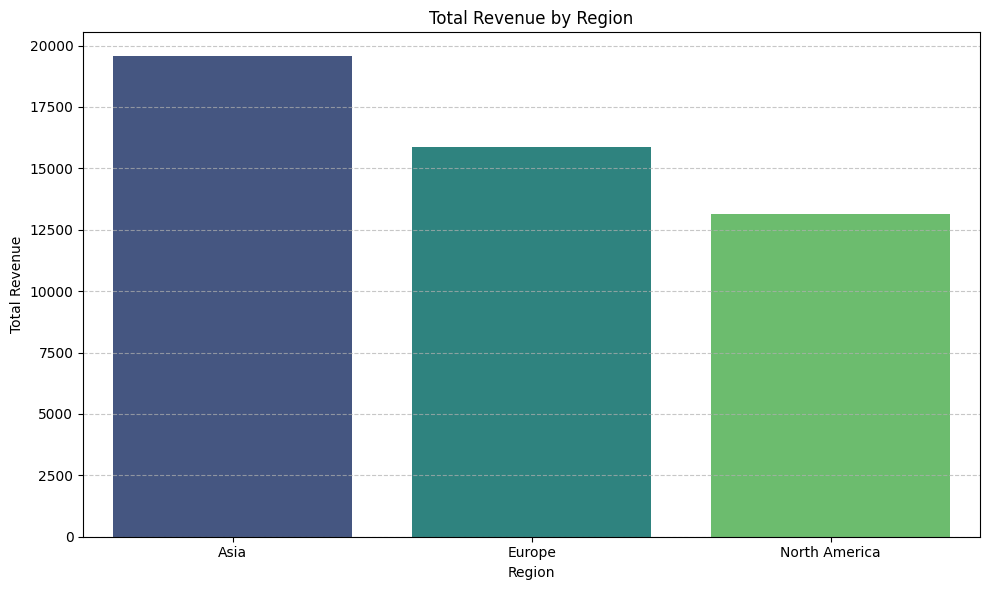

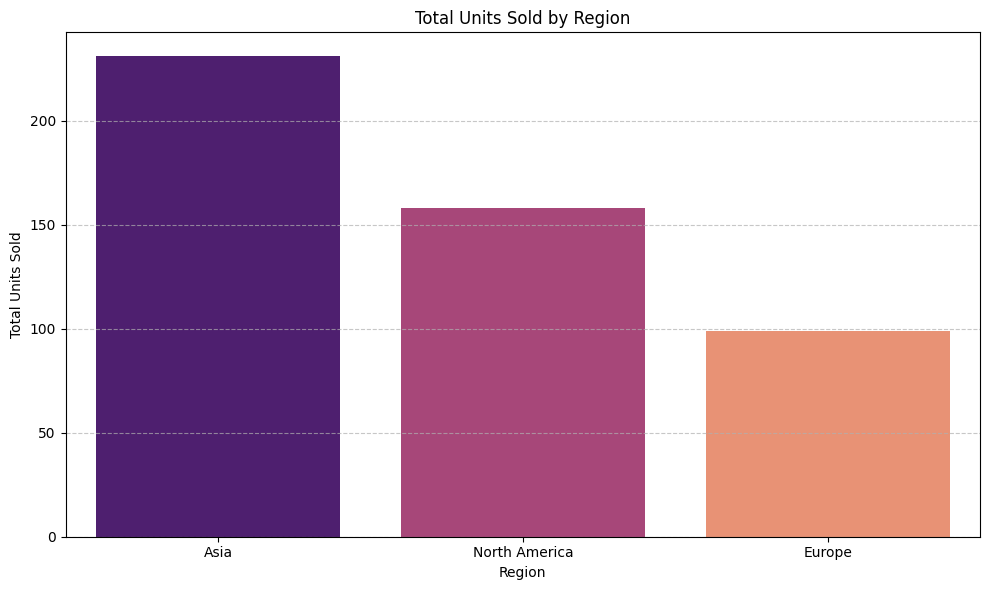

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Region and calculate total revenue and units sold
regional_performance = df_cleaned.groupby('Region').agg(
    total_revenue=('Total Revenue', 'sum'),
    total_units_sold=('Units Sold', 'sum'),
    average_unit_price=('Unit Price', 'mean') # Also check average unit price per region
).reset_index()

print("Regional Sales Performance:")
display(regional_performance.sort_values(by='total_revenue', ascending=False))

# Visualize Regional Total Revenue
plt.figure(figsize=(10, 6))
sns.barplot(x='Region', y='total_revenue', data=regional_performance.sort_values(by='total_revenue', ascending=False), palette='viridis', hue='Region', legend=False)
plt.title('Total Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Total Revenue')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Visualize Regional Units Sold
plt.figure(figsize=(10, 6))
sns.barplot(x='Region', y='total_units_sold', data=regional_performance.sort_values(by='total_units_sold', ascending=False), palette='magma', hue='Region', legend=False)
plt.title('Total Units Sold by Region')
plt.xlabel('Region')
plt.ylabel('Total Units Sold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Regional Distribution of Customer Segments

To further understand 'neighbourhood impact', let's examine how our previously identified customer clusters (from K-Means segmentation) are distributed across these regions. This can reveal if certain customer types are concentrated in specific geographical areas.

Cluster Distribution by Region:


Cluster,0,1,2
Region,,,
Asia,40,38,0
Europe,39,0,38
North America,43,0,23


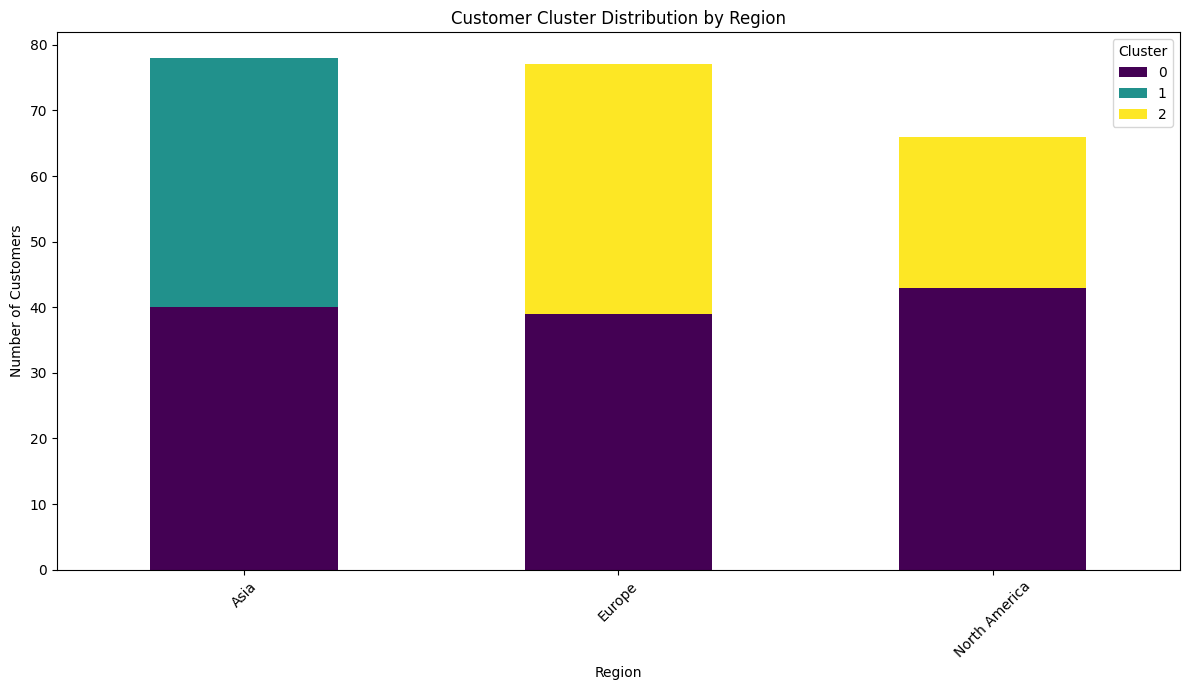

In [57]:
# Analyze cluster distribution by region
cluster_regional_distribution = df_cleaned_with_clusters.groupby(['Region', 'Cluster']).size().unstack(fill_value=0)

print("Cluster Distribution by Region:")
display(cluster_regional_distribution)

# Visualize Cluster Distribution by Region
cluster_regional_distribution.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')
plt.title('Customer Cluster Distribution by Region')
plt.xlabel('Region')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

### Insights from Regional Analysis:

Based on the regional sales performance and customer cluster distribution, we can draw the following insights:

*   **Dominant Regions:** Identify which regions contribute most significantly to total revenue and units sold. These are your 'high-impact neighbourhoods' that might require sustained investment or careful management.
*   **Regional Specialization:** Some regions might show a preference for certain product categories or attract specific customer segments (e.g., Cluster 2 customers, who buy Home Appliances, might be concentrated in certain regions).
*   **Growth Opportunities:** Regions with lower current performance but a good presence of high-value customer segments (e.g., Cluster 2) could represent untapped growth opportunities.

### Regional Recommendations:

*   **Geographically Targeted Campaigns:** Tailor marketing campaigns to the specific preferences and characteristics of each region and its dominant customer segments. For example, promoting sports equipment in regions with a high proportion of Cluster 1 customers.
*   **Localized Product Offerings:** Consider offering region-specific product bundles or promotions based on local demand identified through this analysis.
*   **Resource Allocation:** Allocate sales and marketing resources strategically, focusing on high-performing regions to maintain momentum, and on high-potential regions for growth.
*   **Logistics and Supply Chain:** Optimize logistics and inventory management based on regional demand patterns to ensure efficient delivery and reduce costs.